<a href="https://colab.research.google.com/github/harendradadhich/notebooks/blob/main/Retail_Sales_Prediction_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <b><u> Project Title : Sales Prediction : Predicting sales of a major store chain Rossmann</u></b>

## <b> Problem Description </b>

### Rossmann operates over 3,000 drug stores in 7 European countries. Currently, Rossmann store managers are tasked with predicting their daily sales for up to six weeks in advance. Store sales are influenced by many factors, including promotions, competition, school and state holidays, seasonality, and locality. With thousands of individual managers predicting sales based on their unique circumstances, the accuracy of results can be quite varied.

### You are provided with historical sales data for 1,115 Rossmann stores. The task is to forecast the "Sales" column for the test set. Note that some stores in the dataset were temporarily closed for refurbishment.

## <b> Data Description </b>

### <b>Rossmann Stores Data.csv </b> - historical data including Sales
### <b>store.csv </b> - supplemental information about the stores


### <b><u>Data fields</u></b>
### Most of the fields are self-explanatory. The following are descriptions for those that aren't.

* #### Id - an Id that represents a (Store, Date) duple within the test set
* #### Store - a unique Id for each store
* #### Sales - the turnover for any given day (this is what you are predicting)
* #### Customers - the number of customers on a given day
* #### Open - an indicator for whether the store was open: 0 = closed, 1 = open
* #### StateHoliday - indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays. Note that all schools are closed on public holidays and weekends. a = public holiday, b = Easter holiday, c = Christmas, 0 = None
* #### SchoolHoliday - indicates if the (Store, Date) was affected by the closure of public schools
* #### StoreType - differentiates between 4 different store models: a, b, c, d
* #### Assortment - describes an assortment level: a = basic, b = extra, c = extended
* #### CompetitionDistance - distance in meters to the nearest competitor store
* #### CompetitionOpenSince[Month/Year] - gives the approximate year and month of the time the nearest competitor was opened
* #### Promo - indicates whether a store is running a promo on that day
* #### Promo2 - Promo2 is a continuing and consecutive promotion for some stores: 0 = store is not participating, 1 = store is participating
* #### Promo2Since[Year/Week] - describes the year and calendar week when the store started participating in Promo2
* #### PromoInterval - describes the consecutive intervals Promo2 is started, naming the months the promotion is started anew. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store

## Loading Libraries & Data

In [1]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import missingno as msno
import matplotlib
import matplotlib.pylab as pylab

%matplotlib inline
matplotlib.style.use('ggplot')
sns.set_style('white')
pylab.rcParams['figure.figsize'] = 8,6

import math
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import LassoLars
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import ElasticNet

In [2]:
# #mounting drive
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
#Loading Rossman Dataset
rossman_df= pd.read_csv('train.csv', low_memory= False)

In [4]:
#Loading Store Dataset
store_df=pd.read_csv('store.csv', low_memory= False)

## **Analysing the Rossman Dataset**

In [5]:
rossman_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [6]:
rossman_df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1
1017208,1115,2,2013-01-01,0,0,0,0,a,1


##### **Checking Information about Dataset**

In [7]:
rossman_df.shape

(1017209, 9)

In [8]:
#Checking info of data as data types and rows and cols
rossman_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [9]:
#Checking Null Values
rossman_df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


**Summary Statastics Of Dataset**

In [10]:
#Summary Statastics
rossman_df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [11]:
#No. Of Stores in the Dataset
rossman_df.Store.nunique()

1115

In [12]:
# Value_counts of StateHoliday Column
rossman_df.StateHoliday.value_counts()

,count
StateHoliday,
0,986159
a,20260
b,6690
c,4100


In [13]:
print(rossman_df['Date'].min(),'initial')
print(rossman_df['Date'].max(),'final')

2013-01-01 initial
2015-07-31 final


**This tells us we have a data of almost 3 years.**

In [14]:
# extract year, month, day and week of year from "Date"

rossman_df['Date']=pd.to_datetime(rossman_df['Date'])
rossman_df['Year'] = rossman_df['Date'].apply(lambda x: x.year)
rossman_df['Month'] = rossman_df['Date'].apply(lambda x: x.month)
rossman_df['Day'] = rossman_df['Date'].apply(lambda x: x.day)
rossman_df['WeekOfYear'] = rossman_df['Date'].apply(lambda x: x.weekofyear)

In [15]:
rossman_df.sort_values(by=['Date','Store'],inplace=True,ascending=[False,True])
rossman_df.head(2)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,31


## **EDA On Rossman Dataset**

#### **Heatmap of the Rossman Dataset**

<Axes: >

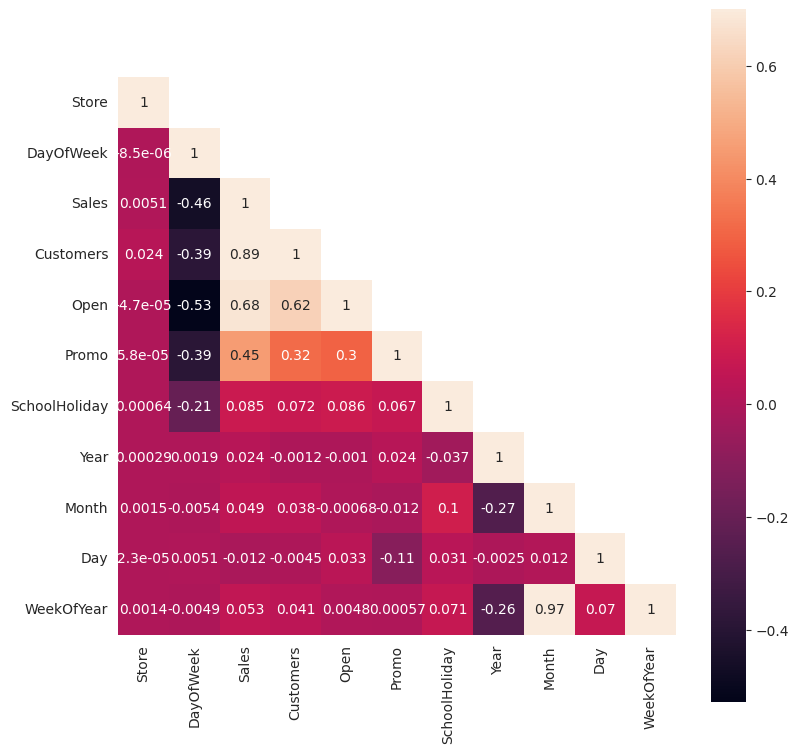

In [21]:
correlation_map = rossman_df.select_dtypes(include=np.number).corr()
obj = np.array(correlation_map)
obj[np.tril_indices_from(obj)] = False
fig,ax= plt.subplots()
fig.set_size_inches(9,9)
sns.heatmap(correlation_map, mask=obj,vmax=.7, square=True,annot=True)

**As we can see that in the graph given below that Stores mainly closed on Sunday**

<Axes: xlabel='DayOfWeek', ylabel='count'>

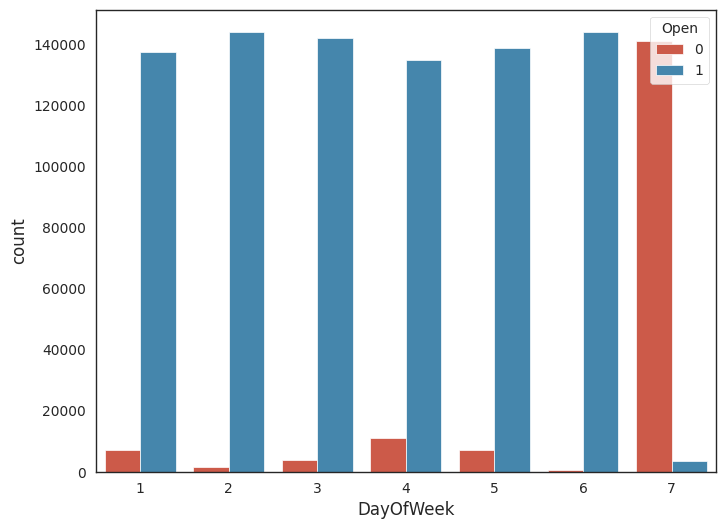

In [22]:
sns.countplot(x='DayOfWeek',hue='Open',data=rossman_df)

**Sales Are nearly doubled High When Promo is Running**

<Axes: xlabel='Promo', ylabel='Sales'>

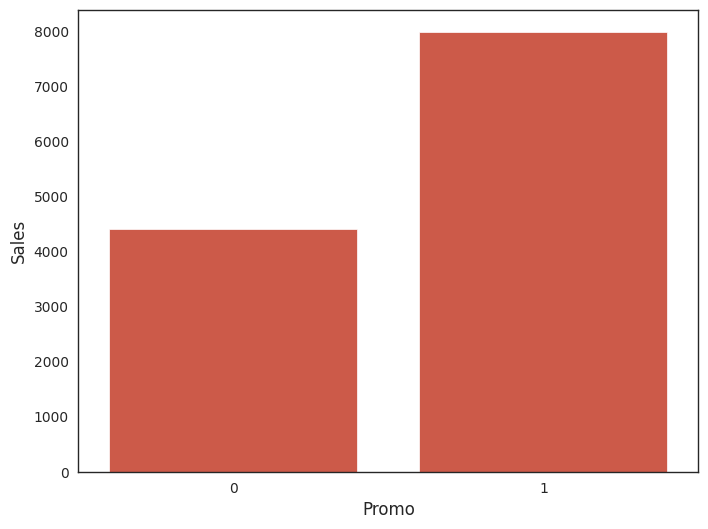

In [23]:
#Impact of promo on sales
Promo_sales = pd.DataFrame(rossman_df.groupby('Promo').agg({'Sales':'mean'}))
sns.barplot(x=Promo_sales.index, y = Promo_sales['Sales'])

In [27]:
rossman_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,2013,1,1,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1,2013,1,1,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1,2013,1,1,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1,2013,1,1,1


**As We can see that In the month of November and Specially in December Sales is increasing Rapidly every year on the christmas eve.**

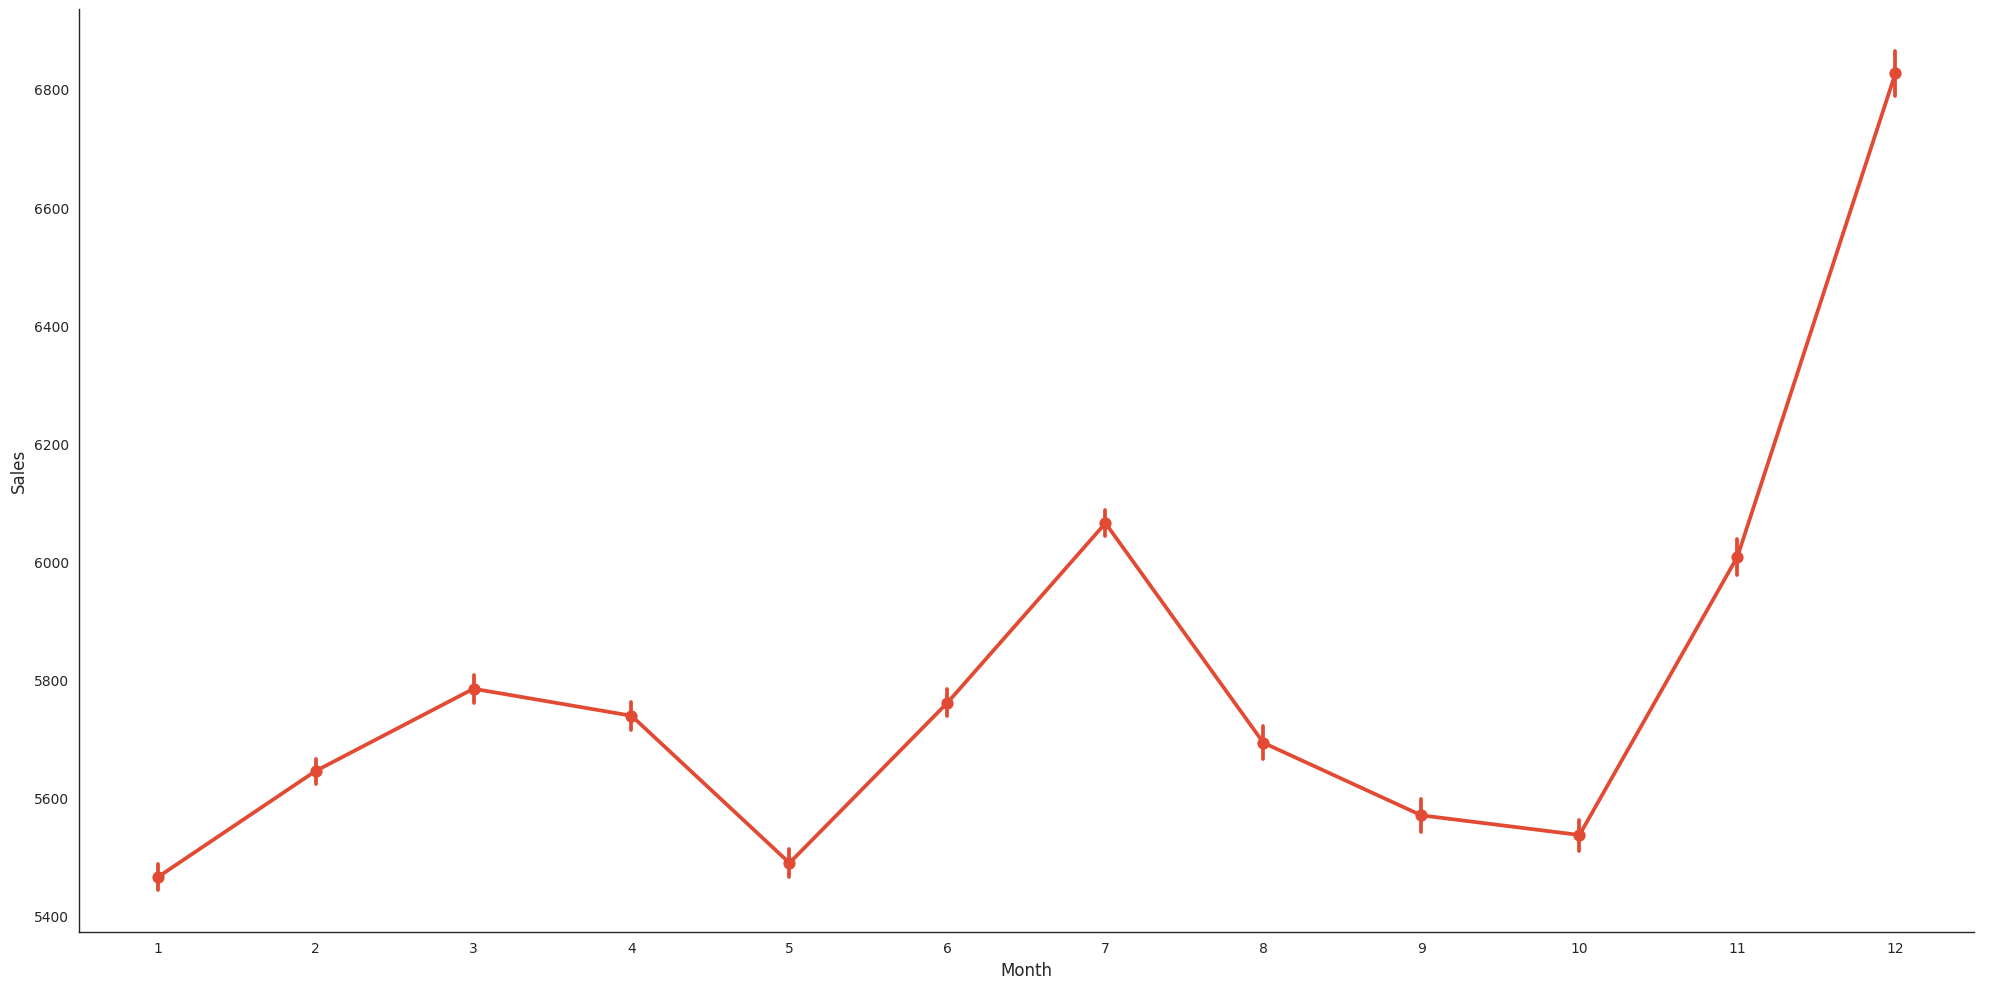

In [26]:
sns.catplot(x="Month" ,y = "Sales" , data=rossman_df, kind="point", aspect=2,height=10)

In [28]:
# Value Counts of SchoolHoliday Column
rossman_df.SchoolHoliday.value_counts()

,count
SchoolHoliday,
0,835488
1,181721


**As we can see in the Piechart Sales affected by School Holiday is 18% and Mainly Sales aren't afffected by School Holiday**

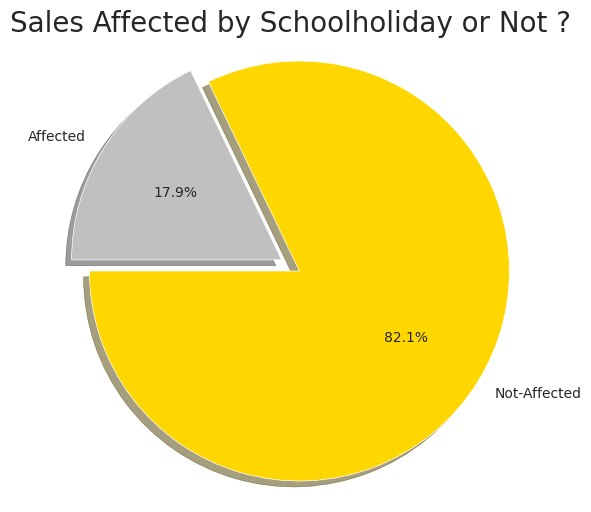

In [29]:
labels = 'Not-Affected' , 'Affected'
sizes = rossman_df.SchoolHoliday.value_counts()
colors = ['gold', 'silver']
explode = (0.1, 0.0)
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=180)
plt.axis('equal')
plt.title("Sales Affected by Schoolholiday or Not ?",fontsize=20)
plt.plot()
fig=plt.gcf()
fig.set_size_inches(6,6)
plt.show()


### **Transforming Variable StateHoliday**

In [30]:
rossman_df["StateHoliday"] = rossman_df["StateHoliday"].map({0: 0, "0": 0, "a": 1, "b": 1, "c": 1})

In [31]:
rossman_df.StateHoliday.value_counts()

,count
StateHoliday,
0,986159
1,31050


**As we can see in the Piechart Sales affected by State Holiday is only 3% means Sales aren't afffected by State Holiday**

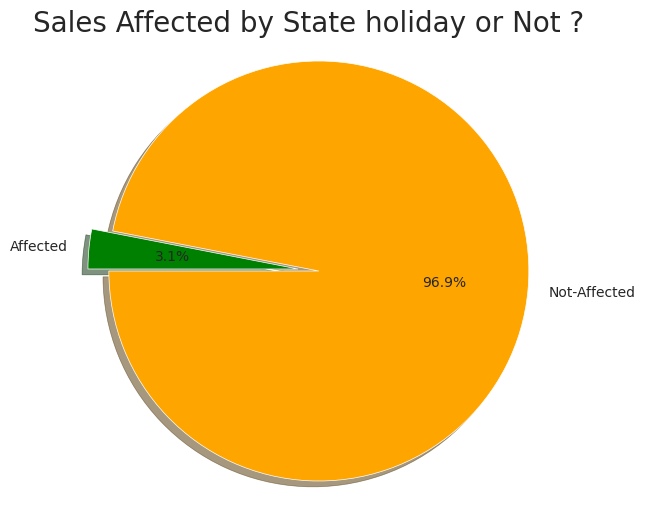

In [32]:
labels = 'Not-Affected' , 'Affected'
sizes = rossman_df.StateHoliday.value_counts()
colors = ['orange','green']
explode = (0.1, 0.0)
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=180)
plt.axis('equal')
plt.title("Sales Affected by State holiday or Not ?",fontsize=20)
plt.plot()
fig=plt.gcf()
fig.set_size_inches(6,6)
plt.show()

**As Sales isn't much affected by State Holiday so i'm removing this column**

In [33]:
rossman_df.drop('StateHoliday',inplace=True,axis=1)

**Histogram Representation of Sales. Here 0 is showing because most of the time store was closed.**

/tmp/ipython-input-2144428938.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(rossman_df['Sales'], kde = False,bins=40);


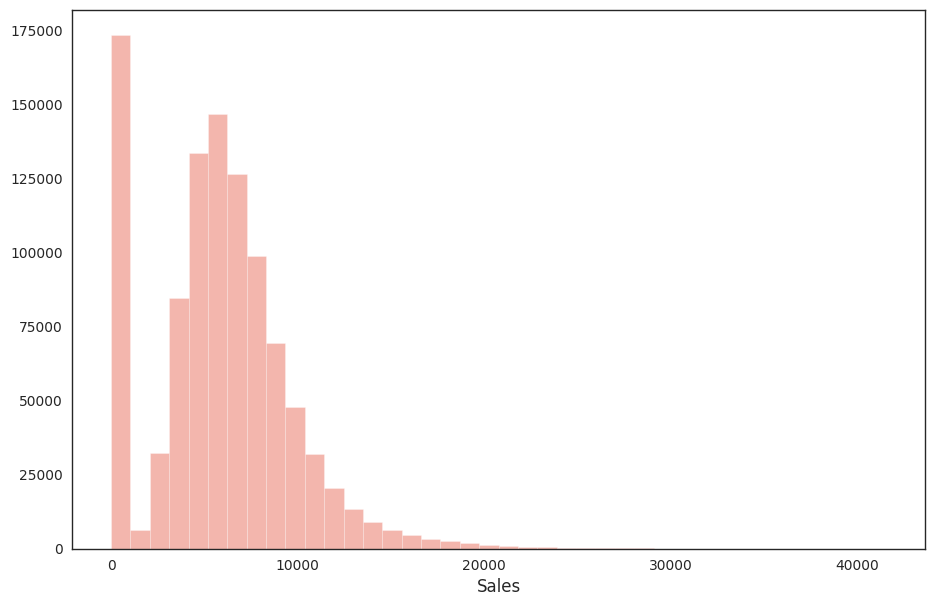

In [34]:
#distribution of sales
fig, ax = plt.subplots()
fig.set_size_inches(11, 7)
sns.distplot(rossman_df['Sales'], kde = False,bins=40);

**Sales vs Customers**

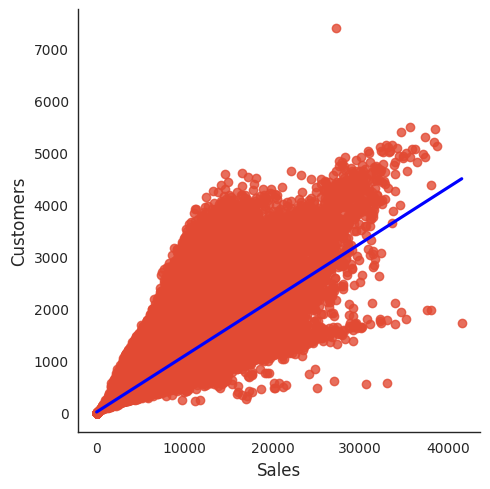

In [35]:
#linear relation between sales and customers
sns.lmplot(x= 'Sales' , y ='Customers',data=rossman_df, palette='seismic', height=5,aspect=1, line_kws={'color':'blue'});

## **Analysing the Store Dataset**

In [16]:
store_df.head(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [17]:
store_df.tail()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN
1114,1115,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"


##### **Checking Information about Dataset**

In [18]:
store_df.shape

(1115, 10)

In [19]:
#Checking info of data as data types and rows and cols
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [20]:
#Checking Null Values
store_df.isnull().sum()

,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,3
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
Promo2,0
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544


**Heatmap for null values**

<Axes: >

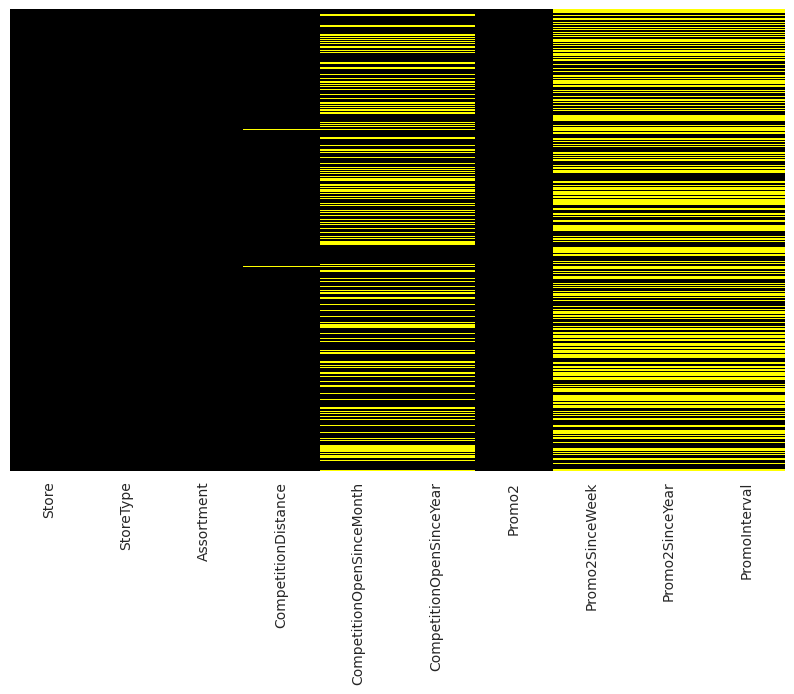

In [21]:
# creating heatmap for null values
plt.figure(figsize=(10,6))
sns.heatmap(store_df.isnull(),yticklabels= False, cbar= False, cmap= 'gnuplot')

**Distribution Of Different Store Types**

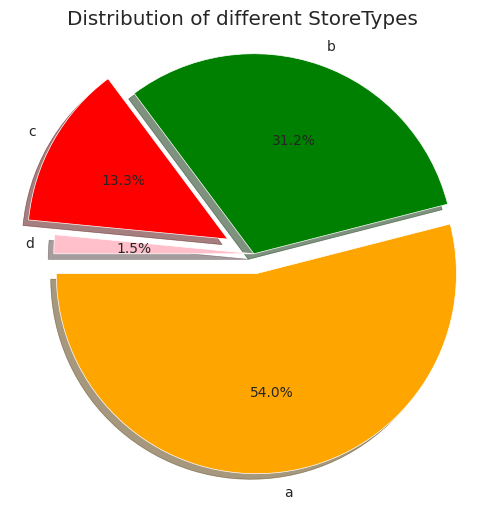

In [22]:
labels = 'a' , 'b' , 'c' , 'd'
sizes = store_df.StoreType.value_counts()
colors = ['orange', 'green' , 'red' , 'pink']
explode = (0.1, 0.0 , 0.15 , 0.0)
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=180)
plt.axis('equal')
plt.title("Distribution of different StoreTypes")
plt.plot()
fig=plt.gcf()
fig.set_size_inches(6,6)
plt.show()


#### **The distribution is right skewed, so we'll replace missing values with the median.**

In [23]:
# replace missing values in CompetitionDistance with median for the store dataset

store_df.CompetitionDistance.fillna(store_df.CompetitionDistance.median(), inplace=True)

/tmp/ipython-input-2781003425.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  store_df.CompetitionDistance.fillna(store_df.CompetitionDistance.median(), inplace=True)


**Pairplot for Store Dataset**

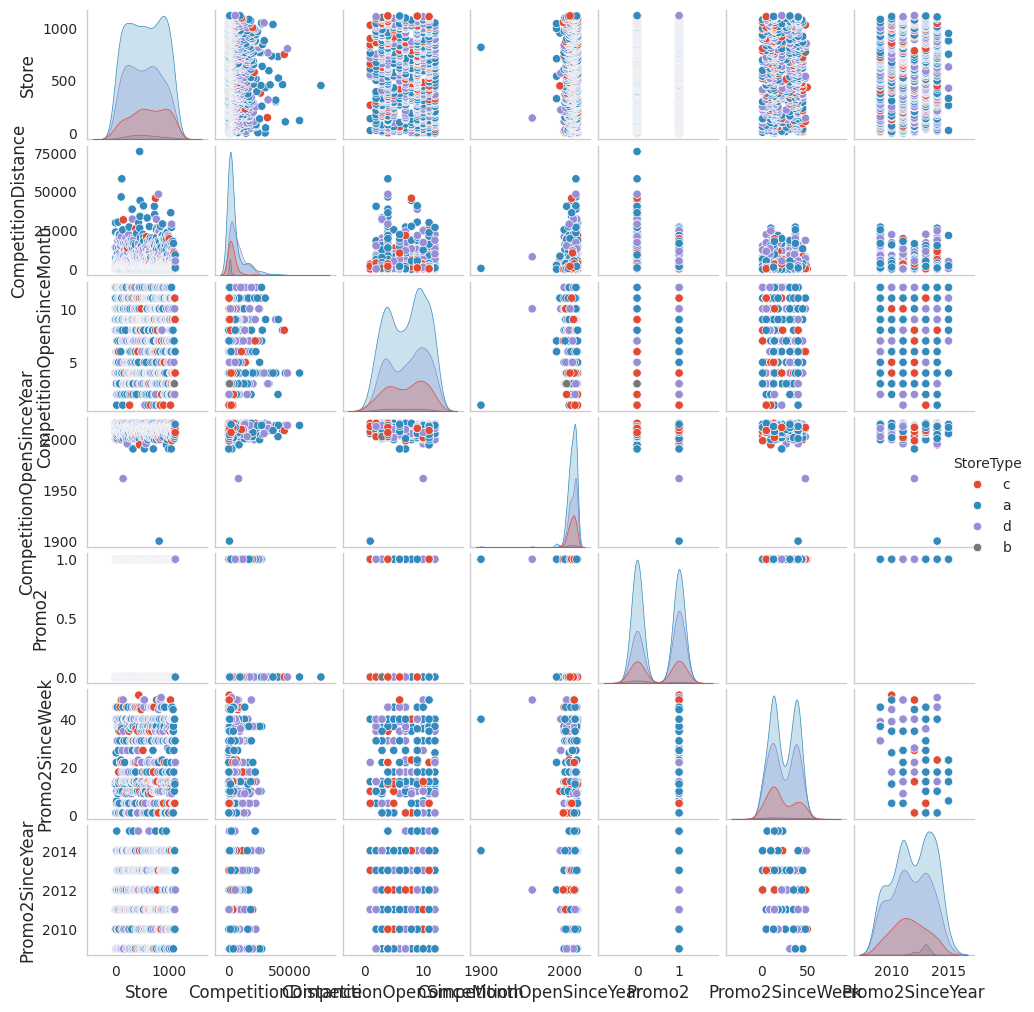

In [24]:
#pairplot for store dataset
sns.set_style("whitegrid", {'axes.grid' : False})
pp=sns.pairplot(store_df,hue='StoreType')
pp.fig.set_size_inches(10,10);

**Checking stores with their assortment type**

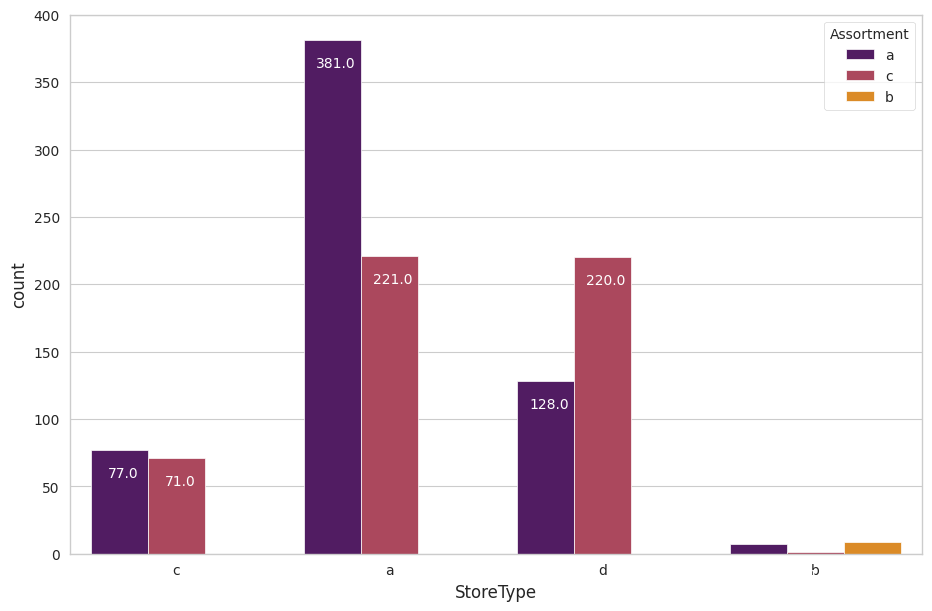

In [25]:
#checking stores with their assortment type
sns.set_style("whitegrid")
fig, ax = plt.subplots()
fig.set_size_inches(11, 7)
store_type=sns.countplot(x='StoreType',hue='Assortment', data=store_df,palette="inferno")

for p in store_type.patches:
    store_type.annotate(f'\n{p.get_height()}', (p.get_x()+0.15, p.get_height()),ha='center', va='top', color='white', size=10)

***We can see that there is not such significant differences in these 3 years in terms of sales.***

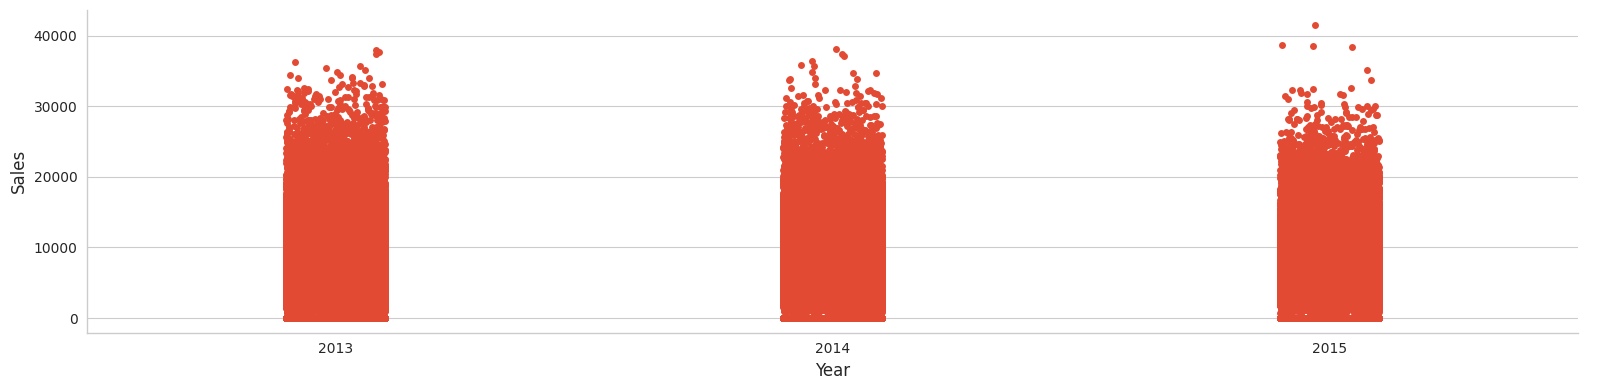

In [26]:
#plotting year vs sales
sns.catplot(x='Year',y='Sales',data=rossman_df, height=4, aspect=4 );

### **Merging Two Datasets**

In [27]:
df = pd.merge(rossman_df, store_df, how='left', on='Store')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,...,WeekOfYear,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,...,31,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,...,31,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,...,31,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,...,31,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,...,31,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [28]:
df.shape

(1017209, 22)

## **EDA On Merged Dataset**

#### **Heatmap Of Merged Dataset**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

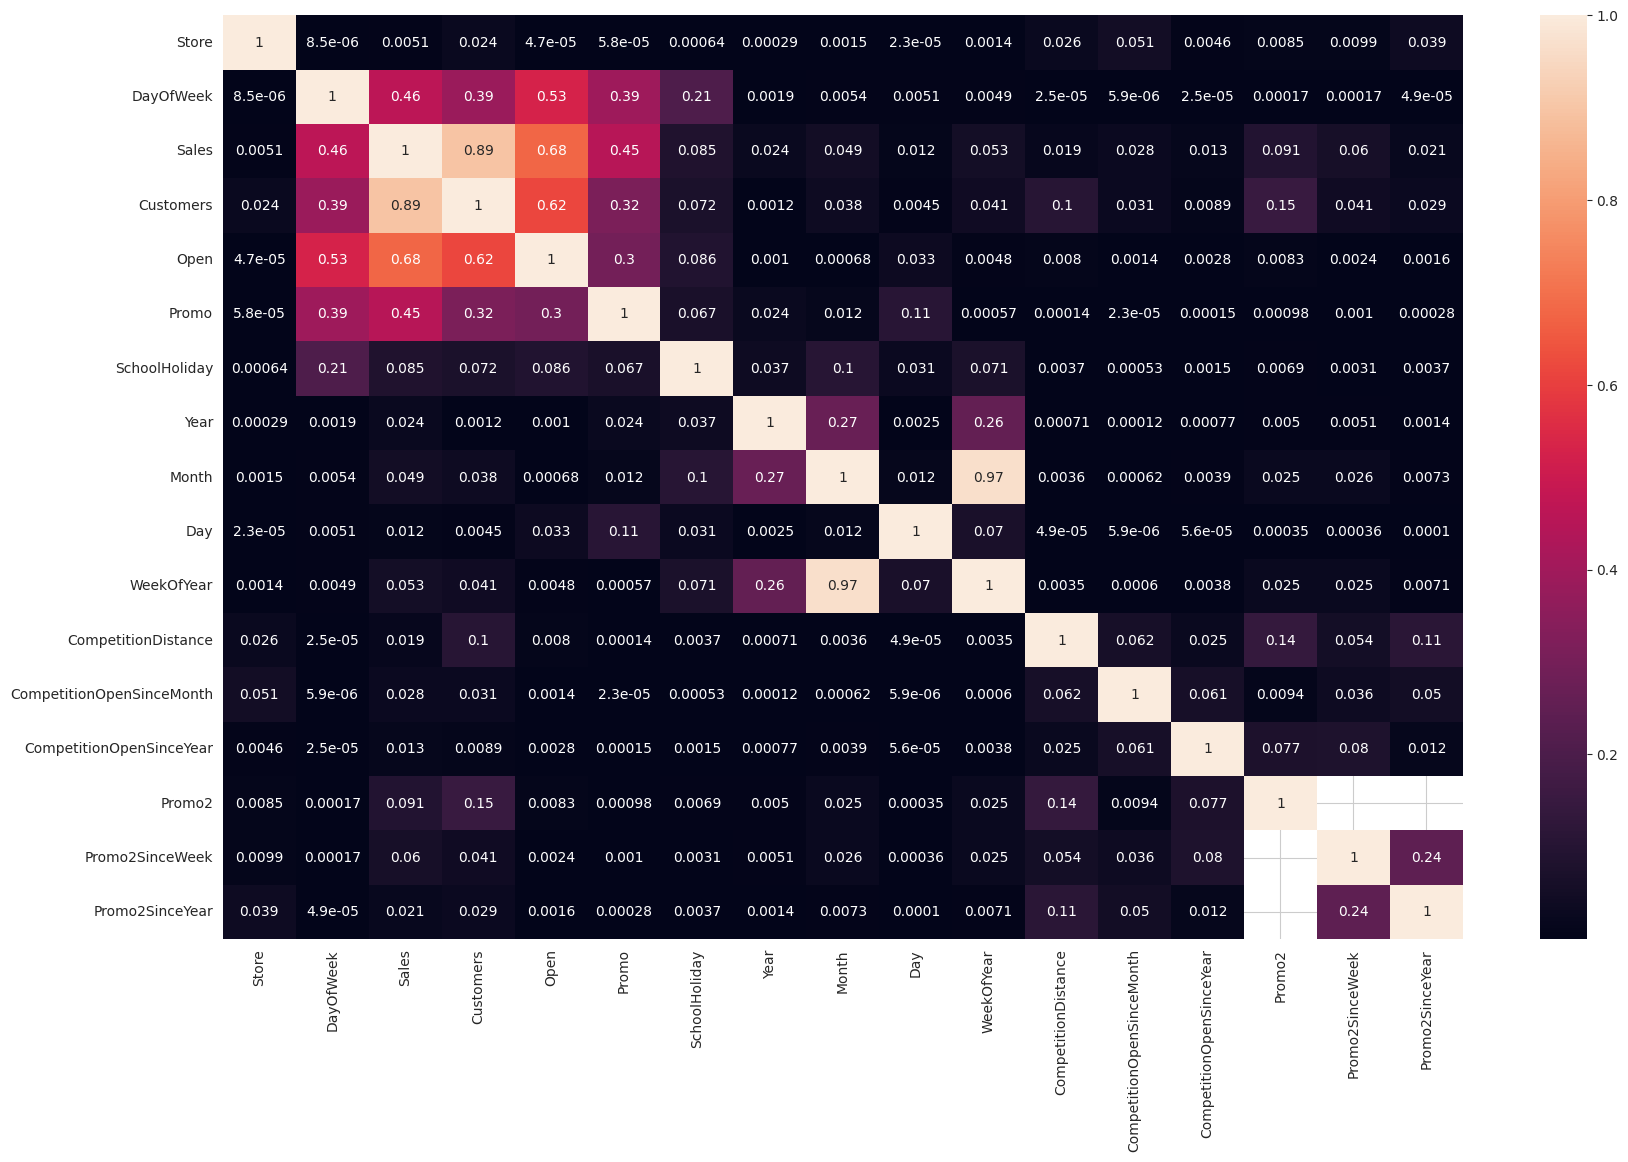

In [29]:
plt.subplots(figsize=(20,12))
sns.heatmap(df.select_dtypes(include=np.number).corr().abs(), annot=True)
plt.savefig("heatmap.png")

from google.colab import files
files.download('heatmap.png') # this line opens your documents in your pc to save your png

In [30]:
df["Avg_Customer_Sales"] = df.Sales/df.Customers

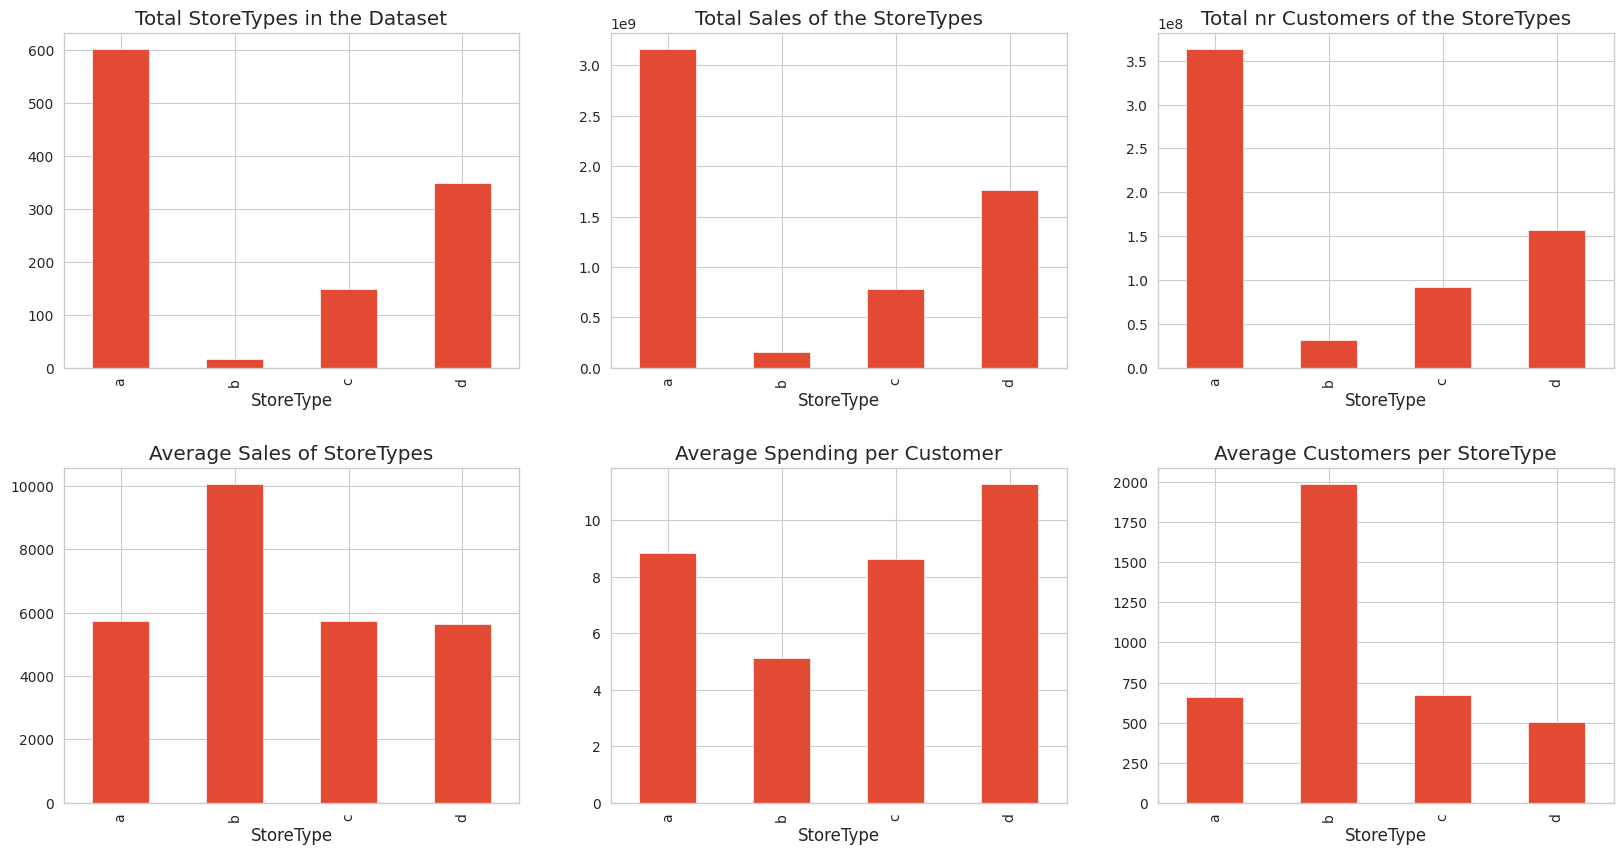

In [31]:
f, ax = plt.subplots(2, 3, figsize = (20,10))

store_df.groupby("StoreType")["Store"].count().plot(kind = "bar", ax = ax[0, 0], title = "Total StoreTypes in the Dataset")
df.groupby("StoreType")["Sales"].sum().plot(kind = "bar", ax = ax[0,1], title = "Total Sales of the StoreTypes")
df.groupby("StoreType")["Customers"].sum().plot(kind = "bar", ax = ax[0,2], title = "Total nr Customers of the StoreTypes")
df.groupby("StoreType")["Sales"].mean().plot(kind = "bar", ax = ax[1,0], title = "Average Sales of StoreTypes")
df.groupby("StoreType")["Avg_Customer_Sales"].mean().plot(kind = "bar", ax = ax[1,1], title = "Average Spending per Customer")
df.groupby("StoreType")["Customers"].mean().plot(kind = "bar", ax = ax[1,2], title = "Average Customers per StoreType")

plt.subplots_adjust(hspace = 0.3)
plt.show()

**As we can see from the graphs, the StoreType A has the most stores, sales and customers. However the StoreType D has the best averages spendings per customers. StoreType B, with only 17 stores has the most average customers.**

#### **Lets go ahead with the promotions**

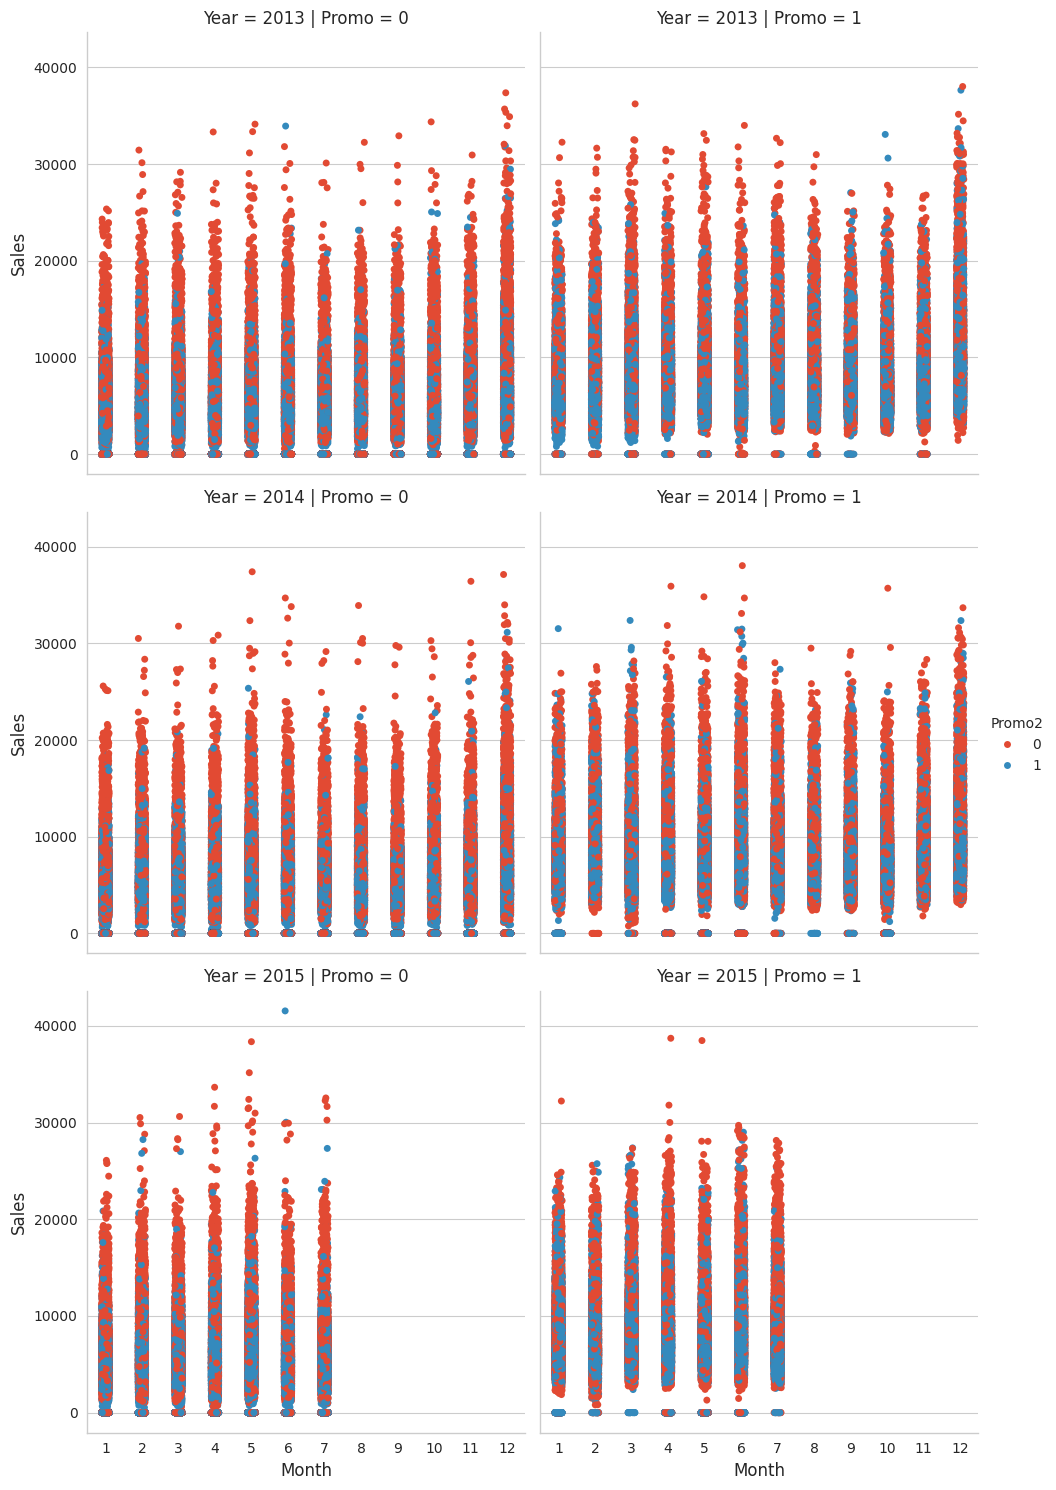

In [37]:
sns.catplot(data = df, x ="Month", y = "Sales",

               col = 'Promo', # per store type in cols
               hue = 'Promo2',
               row = "Year"
             )

**As We can see that when the promo is running Sales are high**

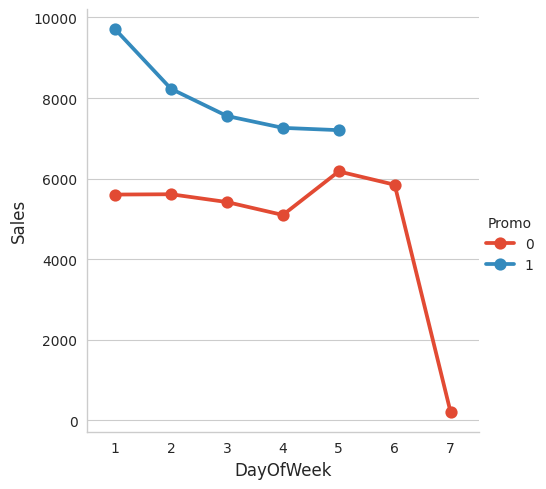

In [45]:
sns.catplot(data = df, x = "DayOfWeek", y = "Sales", kind='point',hue = "Promo")

In [38]:
print("""So, no promotion in the weekend. However, the sales are very high, if the stores have promotion.
The Sales are going crazy on Sunday. No wonder.""")
print("There are", df[(df.Open == 1) & (df.DayOfWeek == 7)].Store.unique().shape[0], "stores opend on sundays")

So, no promotion in the weekend. However, the sales are very high, if the stores have promotion. 
The Sales are going crazy on Sunday. No wonder.
There are 33 stores opend on sundays


**Let's see the trends on a yearly basis.**

<Figure size 1500x700 with 0 Axes>

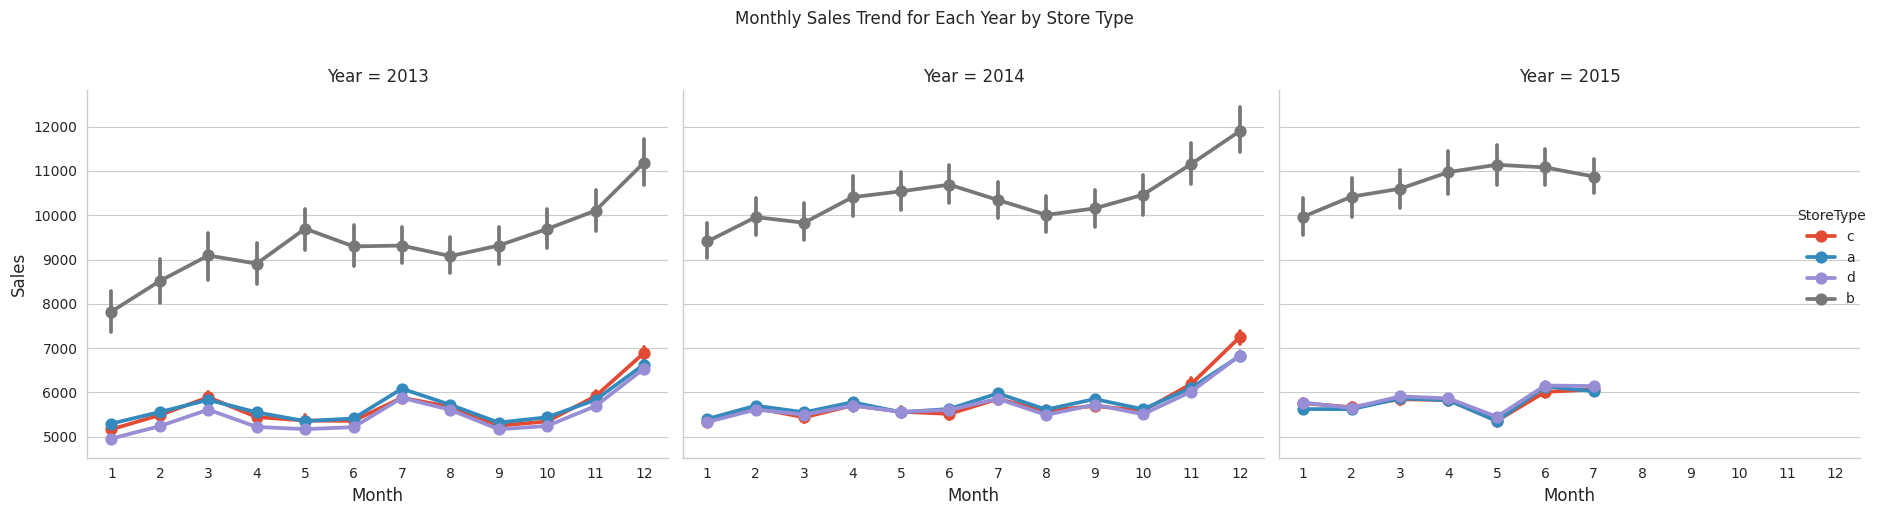

In [44]:
plt.figure(figsize=(15, 7))
sns.catplot(data = df, x = "Month", y = "Sales", col = "Year", hue = "StoreType", kind="point", aspect=1.2, height=5)
plt.suptitle('Monthly Sales Trend for Each Year by Store Type', y=1.02) # Add a suptitle for the entire figure
plt.tight_layout()
plt.show()

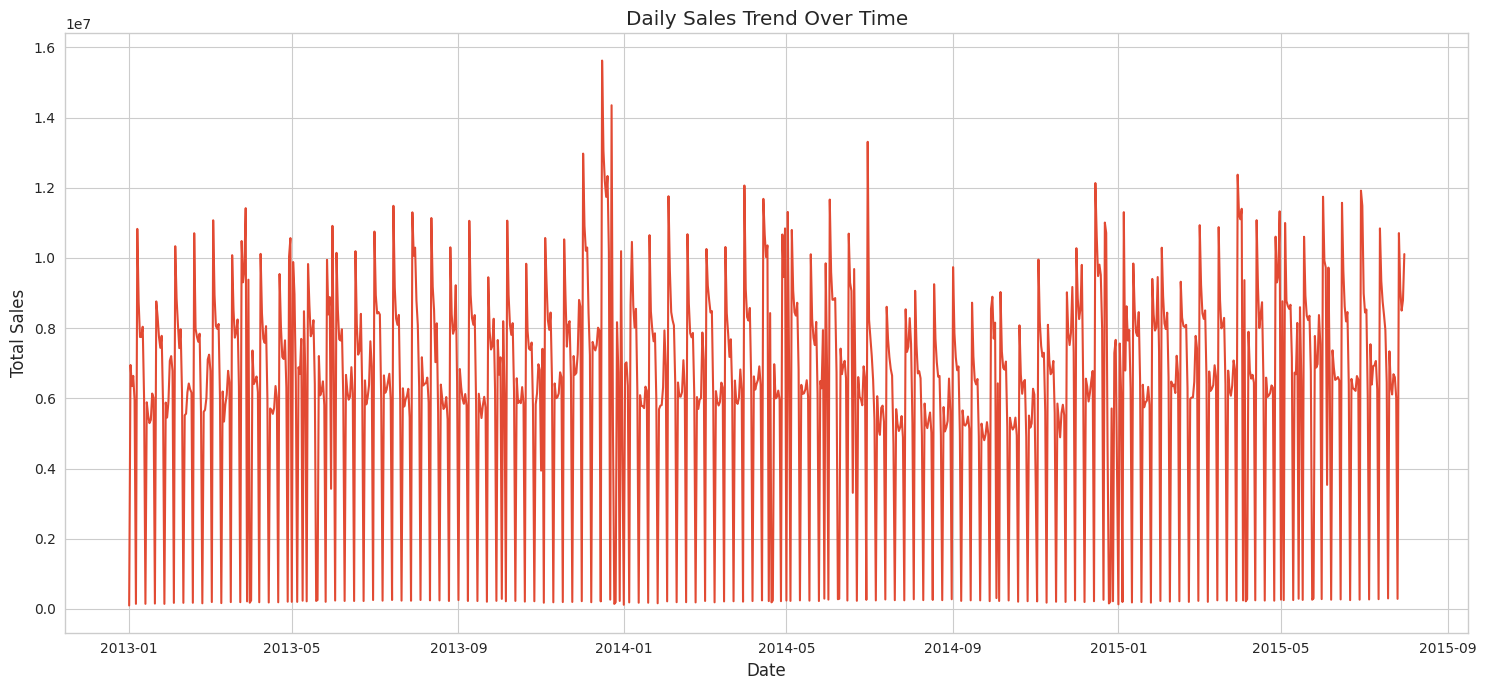

In [43]:
daily_sales_trend = df.groupby('Date')['Sales'].sum().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Sales', data=daily_sales_trend)
plt.title('Daily Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

**What about the Competition Distance. What kind of inpact does this have on the sales.**

In [46]:
df.CompetitionDistance.describe()
# The obsverations are continous numbers, so we need to convert them into a categories. Lets a create a new variable.
df["CompetitionDistance_Cat"] = pd.cut(df["CompetitionDistance"], 5)

/tmp/ipython-input-2097891435.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(by = "CompetitionDistance_Cat").Sales.mean().plot(kind = "bar", title = "Average Total Sales by Competition Distance", ax = ax[0])
/tmp/ipython-input-2097891435.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(by = "CompetitionDistance_Cat").Customers.mean().plot(kind = "bar", title = "Average Total Customers by Competition Distance", ax = ax[1])


<Axes: title={'center': 'Average Total Customers by Competition Distance'}, xlabel='CompetitionDistance_Cat'>

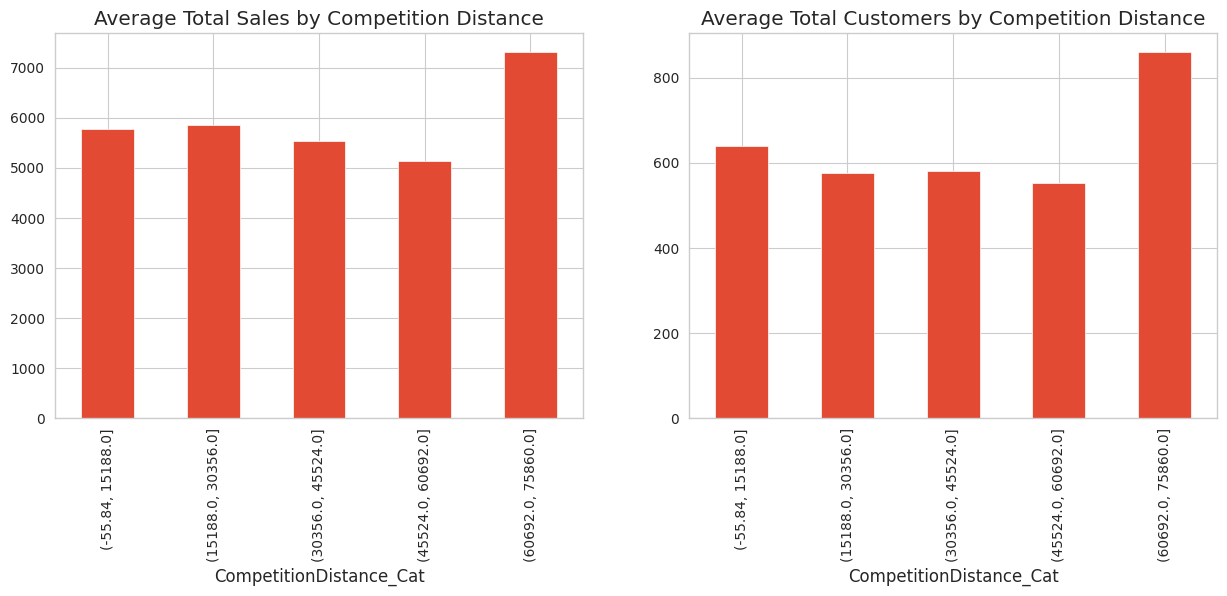

In [47]:
f, ax = plt.subplots(1,2, figsize = (15,5))

df.groupby(by = "CompetitionDistance_Cat").Sales.mean().plot(kind = "bar", title = "Average Total Sales by Competition Distance", ax = ax[0])
df.groupby(by = "CompetitionDistance_Cat").Customers.mean().plot(kind = "bar", title = "Average Total Customers by Competition Distance", ax = ax[1])

# It is pretty clear. If the competions is very far away, the stores are performing better (sales and customers)

In [48]:
# df.drop(['Avg_Customer_Sales','CompetitionDistance_Cat'],axis=1,inplace=True)

## **Conclusion of the analysis:**

**Sales are highly correlated to number of Customers.**

**The most selling and crowded store type is A.**

**StoreType B has the lowest Average Sales per Customer. So i think customers visit this type only for small things.**

**StoreTybe D had the highest buyer cart.**

**Promo runs only in weekdays.**

**For all stores, Promotion leads to increase in Sales and Customers both.**

**More stores are opened during School holidays than State holidays.**

**The stores which are opened during School Holiday have more sales than normal days.**

**Sales are increased during Chirstmas week, this might be due to the fact that people buy more beauty products during a Christmas celebration.**

**Promo2 doesnt seems to be correlated to any significant change in the sales amount.**

**Absence of values in features CompetitionOpenSinceYear/Month doesn’t indicate the absence of competition as CompetitionDistance values are not null where the other two values are null.**

# **Drop Subsets Of Data Where Might Cause Bias**

In [49]:
# where stores are closed, they won't generate sales, so we will remove that part of the dataset
df = df[df.Open != 0]

In [50]:
# Open isn't a variable anymore, so we'll drop it too
df = df.drop('Open', axis=1)

In [51]:
# Check if there's any opened store with zero sales
df[df.Sales == 0]['Store'].sum()

np.int64(31460)

In [52]:
# see the percentage of open stored with zero sales
df[df.Sales == 0]['Sales'].sum()/df.Sales.sum()

np.float64(0.0)

In [53]:
# remove this part of data to avoid bias
df = df[df.Sales != 0]

In [70]:
df_new=df.copy()

In [71]:
df_new = pd.get_dummies(df_new,columns=['StoreType','Assortment','StateHoliday','PromoInterval'])

In [56]:
df_new.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,Year,Month,...,PromoInterval,Avg_Customer_Sales,CompetitionDistance_Cat,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c
0,1,5,2015-07-31,5263,555,1,0,1,2015,7,...,NaN,9.482883,"(-55.84, 15188.0]",False,False,True,False,True,False,False
1,2,5,2015-07-31,6064,625,1,0,1,2015,7,...,"Jan,Apr,Jul,Oct",9.702400,"(-55.84, 15188.0]",True,False,False,False,True,False,False
2,3,5,2015-07-31,8314,821,1,0,1,2015,7,...,"Jan,Apr,Jul,Oct",10.126675,"(-55.84, 15188.0]",True,False,False,False,True,False,False
3,4,5,2015-07-31,13995,1498,1,0,1,2015,7,...,NaN,9.342457,"(-55.84, 15188.0]",False,False,True,False,False,False,True
4,5,5,2015-07-31,4822,559,1,0,1,2015,7,...,NaN,8.626118,"(15188.0, 30356.0]",True,False,False,False,True,False,False


**From plot it can be sen that most of the sales have been on 1st and last day of week**

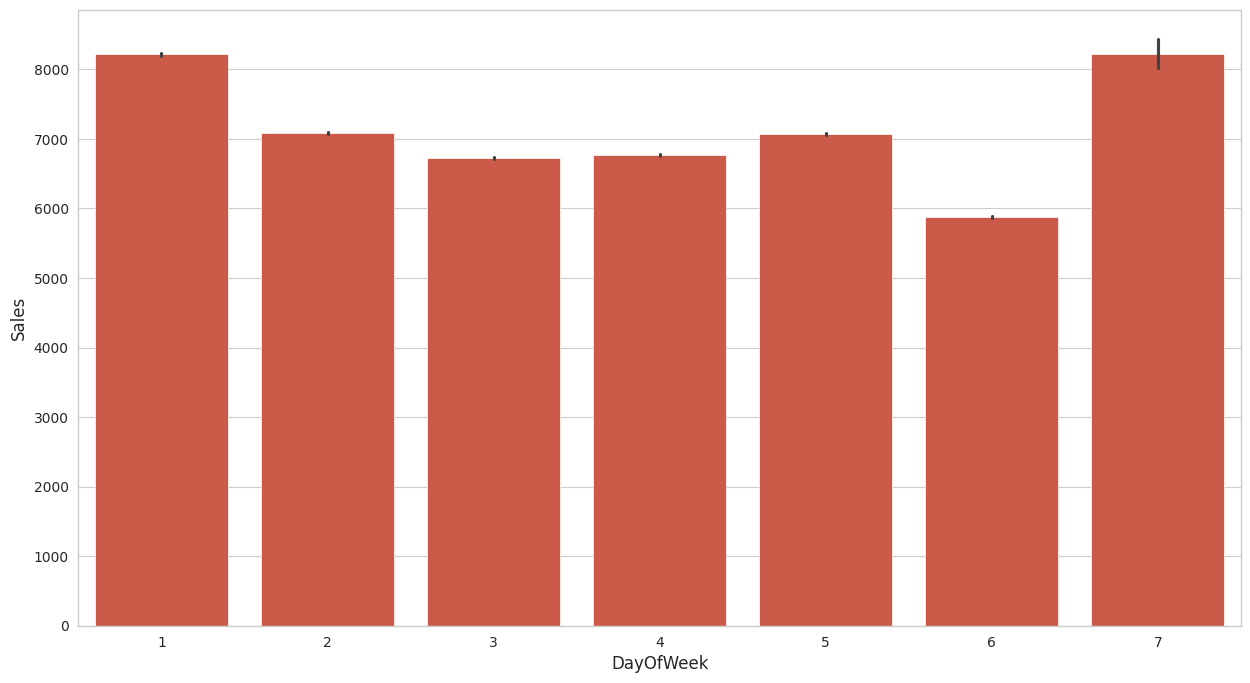

In [57]:
#plot for sales in terms of days ofthe week
plt.figure(figsize=(15,8))
sns.barplot(x='DayOfWeek', y='Sales' ,data=df_new);

In [72]:
df_new

,Store,DayOfWeek,Date,Sales,Customers,Promo,SchoolHoliday,Year,Month,Day,...,Assortment_a,Assortment_b,Assortment_c,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec"
0,1,5,2015-07-31,5263,555,1,1,2015,7,31,...,True,False,False,True,False,False,False,False,False,False
1,2,5,2015-07-31,6064,625,1,1,2015,7,31,...,True,False,False,True,False,False,False,False,True,False
2,3,5,2015-07-31,8314,821,1,1,2015,7,31,...,True,False,False,True,False,False,False,False,True,False
3,4,5,2015-07-31,13995,1498,1,1,2015,7,31,...,False,False,True,True,False,False,False,False,False,False
4,5,5,2015-07-31,4822,559,1,1,2015,7,31,...,True,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,0,1,2013,1,1,...,True,False,False,False,True,False,False,False,False,False
1016827,733,2,2013-01-01,10765,2377,0,1,2013,1,1,...,False,True,False,False,True,False,False,False,False,False
1016863,769,2,2013-01-01,5035,1248,0,1,2013,1,1,...,False,True,False,False,True,False,False,False,True,False
1017042,948,2,2013-01-01,4491,1039,0,1,2013,1,1,...,False,True,False,False,True,False,False,False,False,False


#### **Setting Features and Target Variables**

Light GBM Model with only date parts features without advanced feature engineering

In [68]:
features = ['Store','DayOfWeek','Promo','Year','Month','Day']
X = df_new[features]
y = df_new['Sales']

# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31
}

model = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(stopping_rounds=10)]
)

# Evaluate
y_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f'Validation RMSE: {rmse}')
# # predictions are on log scale (Sales_log); use evaluate_metrics with from_log_scale=True
# evaluate_metrics(y_val, y_pred, 'LightGBM Baseline', from_log_scale=True)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012431 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 314
[LightGBM] [Info] Number of data points in the train set: 675470, number of used features: 6
[LightGBM] [Info] Start training from score 7020.359211
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[343]	valid_0's rmse: 2472.91
Validation RMSE: 2472.9063991760822


#### Advanced Feature Engineering

In [76]:
# Advanced Feature Engineering
#Competition Features

#We'll calculate the number of months a competitor has been open.
#This can help the model understand the impact of competition on sales over time.

# Promotion Features

# We'll create features related to the continuous Promo2 promotion. Specifically, we'll calculate:

# Promo2Open: The duration (in months) that Promo2 has been active for a given store.

# Competition Open Since
for df_temp in [df_new]: # Renamed df to df_temp to avoid confusion with the global df variable if it was ever needed unmodified
    df_temp['CompetitionOpenSinceYear'] = df_temp['CompetitionOpenSinceYear'].fillna(0)
    df_temp['CompetitionOpenSinceMonth'] = df_temp['CompetitionOpenSinceMonth'].fillna(0)
    df_temp['Promo2SinceYear'] = df_temp['Promo2SinceYear'].fillna(0)
    df_temp['Promo2SinceWeek'] = df_temp['Promo2SinceWeek'].fillna(0)

    df_temp['CompetitionOpen'] = 12 * (df_temp['Year'] - df_temp['CompetitionOpenSinceYear']) + \
                               (df_temp['Month'] - df_temp['CompetitionOpenSinceMonth'])
    df_temp['CompetitionOpen'] = df_temp['CompetitionOpen'].apply(lambda x: x if x > 0 else 0)

    df_temp['Promo2Open'] = 12 * (df_temp['Year'] - df_temp['Promo2SinceYear']) + \
                          (df_temp['Month'] - (df_temp['Promo2SinceWeek'] // 4))
    df_temp['Promo2Open'] = df_temp['Promo2Open'].apply(lambda x: x if x > 0 else 0)

# Lag Features (Sales)
df_new = df_new.sort_values(['Store','Date'])
train = df_new

# Drop the categorical column 'CompetitionDistance_Cat' before filling NaNs globally
# as it is not part of the 'features' for the model and causes a TypeError when filling with 0.
if 'CompetitionDistance_Cat' in train.columns:
    train = train.drop('CompetitionDistance_Cat', axis=1)
# Also drop Avg_Customer_Sales if it's not intended for the model, as it was previously created
if 'Avg_Customer_Sales' in train.columns:
    train = train.drop('Avg_Customer_Sales', axis=1)

train['Sales_lag1'] = train.groupby('Store')['Sales'].shift(1)
train['Sales_lag7'] = train.groupby('Store')['Sales'].shift(7)

train['Sales_roll7'] = train.groupby('Store')['Sales'].shift(1).rolling(7).mean()
train['Sales_roll30'] = train.groupby('Store')['Sales'].shift(1).rolling(30).mean()

# Fill NA values from lag features and other newly created features
# Now 'CompetitionDistance_Cat' and 'Avg_Customer_Sales' are dropped, fillna(0) should be safe for remaining columns.
train = train.fillna(0)

# Update features
features = ['Store','DayOfWeek','Promo','Year','Month','Day','CompetitionOpen','Promo2Open',
            'Sales_lag1','Sales_lag7','Sales_roll7','Sales_roll30']
X = train[features]

y = train['Sales']

X

,Store,DayOfWeek,Promo,Year,Month,Day,CompetitionOpen,Promo2Open,Sales_lag1,Sales_lag7,Sales_roll7,Sales_roll30
1014980,1,3,0,2013,1,2,52.0,24157.0,0.0,0.0,0.000000,0.000000
1013865,1,4,0,2013,1,3,52.0,24157.0,5530.0,0.0,0.000000,0.000000
1012750,1,5,0,2013,1,4,52.0,24157.0,4327.0,0.0,0.000000,0.000000
1011635,1,6,0,2013,1,5,52.0,24157.0,4486.0,0.0,0.000000,0.000000
1009405,1,1,1,2013,1,7,52.0,24157.0,4997.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
5574,1115,1,1,2015,7,27,24187.0,38.0,6897.0,7264.0,6089.428571,6620.266667
4459,1115,2,1,2015,7,28,24187.0,38.0,10712.0,6083.0,6582.000000,6807.466667
3344,1115,3,1,2015,7,29,24187.0,38.0,8093.0,5074.0,6869.142857,6905.333333
2229,1115,4,1,2015,7,30,24187.0,38.0,7661.0,5342.0,7238.714286,6978.600000


In [78]:
# Re-train with advanced features
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5
}

# FIXED: Use callback API for early stopping
model_adv = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    num_boost_round=200,
    callbacks=[lgb.early_stopping(stopping_rounds=20)]
)

# Evaluate advanced model
y_pred = model_adv.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f'Validation RMSE: {rmse}')



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1693
[LightGBM] [Info] Number of data points in the train set: 675470, number of used features: 12
[LightGBM] [Info] Start training from score 6969.480646
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[112]	valid_0's rmse: 1078.31
Validation RMSE: 1078.3109635471765


array([5460.32127966, 6020.13287387, 5369.26534778, ..., 7975.02279329,
       8592.00911637, 9666.63487788])

In [99]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) *100


mae = mae(y_val, y_pred)
rmse = rmse(y_val, y_pred)
mape = mape(y_val, y_pred)
wape = wape(y_val, y_pred)
print(f"mae",{mae})
print(f"rmse",{rmse})


print(f"mape",{mape})
print(f"wape",{wape})


mae {np.float64(735.4546932357003)}
rmse {np.float64(1078.3109635471765)}
mape {np.float64(12.031373632319491)}
wape {np.float64(10.655870764574368)}


The Mean Absolute Scaled Error (MASE) is an error metric used for evaluating the accuracy of time series forecasts. It is designed to address some limitations of traditional error metrics like Mean Absolute Percentage Error (MAPE) and Mean Squared Error (MSE). MASE is scaled, meaning it normalizes the forecast errors by comparing them with a baseline forecast. This baseline forecast is typically a "naive" forecast, where the predicted value for each time point is equal to the value of the previous time point.

Unlike traditional metrics like MAPE, MASE is scale-independent, making it more suitable for comparing forecasts across different datasets or when the time series data has varying scales.

The primary advantage of MASE is that it handles zero and near-zero values in the time series more effectively than other error metrics. MASE also does not suffer from the problem of undefined errors, which is an issue in MAPE when actual values are zero.



In [98]:

import numpy as np

# Actual and predicted values
actual_values = np.array(y_val)
predicted_values = np.array(y_pred)

# Calculate the absolute error for each prediction
absolute_errors = np.abs(actual_values - predicted_values)

# Calculate the mean absolute error of the naive forecast
naive_forecast_errors = np.abs(np.diff(actual_values))
naive_mae = np.mean(naive_forecast_errors)

# Calculate MASE
mase = np.mean(absolute_errors) / naive_mae
print(f"Mean Absolute Scaled Error (MASE): {mase:.4f}")

Mean Absolute Scaled Error (MASE): 0.5224


In [ ]:
sMAPE = np.mean(2 * np.abs(actual_values - predicted_values) / (np.abs(actual_values) + np.abs(predicted_values))) * 100
print(f"Symmetric Mean Absolute Percentage Error (sMAPE): {sMAPE:.2f}%")


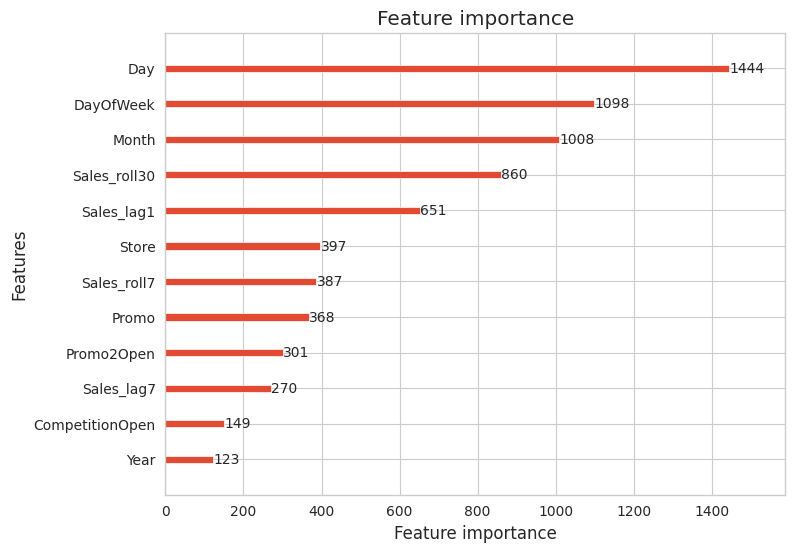

In [100]:
# Feature importance
lgb.plot_importance(model_adv, max_num_features=15)
plt.show()

## Model Explanibility


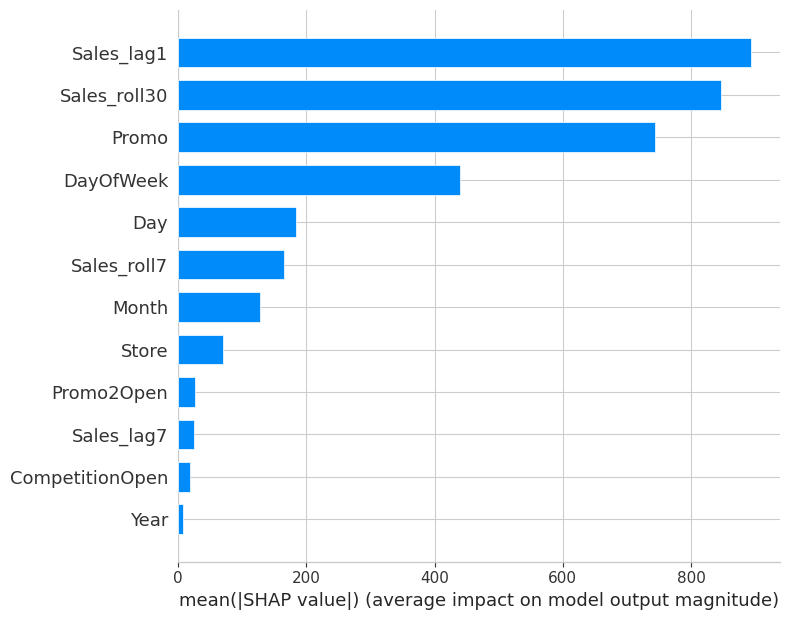

In [102]:
import shap

explainer = shap.TreeExplainer(model_adv)
shap_values = explainer.shap_values(X_val)

shap.summary_plot(shap_values, X_val, plot_type="bar")


## Evaluate Traditional Machine Learning Models

In [103]:
X

,Store,DayOfWeek,Promo,Year,Month,Day,CompetitionOpen,Promo2Open,Sales_lag1,Sales_lag7,Sales_roll7,Sales_roll30
1014980,1,3,0,2013,1,2,52.0,24157.0,0.0,0.0,0.000000,0.000000
1013865,1,4,0,2013,1,3,52.0,24157.0,5530.0,0.0,0.000000,0.000000
1012750,1,5,0,2013,1,4,52.0,24157.0,4327.0,0.0,0.000000,0.000000
1011635,1,6,0,2013,1,5,52.0,24157.0,4486.0,0.0,0.000000,0.000000
1009405,1,1,1,2013,1,7,52.0,24157.0,4997.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
5574,1115,1,1,2015,7,27,24187.0,38.0,6897.0,7264.0,6089.428571,6620.266667
4459,1115,2,1,2015,7,28,24187.0,38.0,10712.0,6083.0,6582.000000,6807.466667
3344,1115,3,1,2015,7,29,24187.0,38.0,8093.0,5074.0,6869.142857,6905.333333
2229,1115,4,1,2015,7,30,24187.0,38.0,7661.0,5342.0,7238.714286,6978.600000


In [124]:
# Create a temporary copy of df_new to avoid modifying the original globally if not intended
temp_df_for_X = df_new.copy()

# Drop target and datetime columns
columns_to_drop_final = ['Sales', 'Date']
temp_df_for_X = temp_df_for_X.drop(columns=columns_to_drop_final, errors='ignore')

# Explicitly drop the problematic CompetitionDistance_Cat column if it exists
if 'CompetitionDistance_Cat' in temp_df_for_X.columns:
    temp_df_for_X = temp_df_for_X.drop('CompetitionDistance_Cat', axis=1)

# Select only numerical columns to ensure compatibility with sklearn models
X = temp_df_for_X.select_dtypes(include=np.number)

# The target variable y remains the 'Sales' column from the original df_new
y = df_new.Sales

In [125]:
X.shape

(844338, 22)

In [126]:
X.head()

,Store,DayOfWeek,Customers,Promo,SchoolHoliday,Year,Month,Day,WeekOfYear,CompetitionDistance,...,Promo2,Promo2SinceWeek,Promo2SinceYear,Avg_Customer_Sales,CompetitionOpen,Promo2Open,Sales_lag1,Sales_lag7,Sales_roll7,Sales_roll30
1014980,1,3,668,0,1,2013,1,2,1,1270.0,...,0,0.0,0.0,8.278443,52.0,24157.0,NaN,NaN,NaN,NaN
1013865,1,4,578,0,1,2013,1,3,1,1270.0,...,0,0.0,0.0,7.486159,52.0,24157.0,5530.0,NaN,NaN,NaN
1012750,1,5,619,0,1,2013,1,4,1,1270.0,...,0,0.0,0.0,7.247173,52.0,24157.0,4327.0,NaN,NaN,NaN
1011635,1,6,635,0,1,2013,1,5,1,1270.0,...,0,0.0,0.0,7.869291,52.0,24157.0,4486.0,NaN,NaN,NaN
1009405,1,1,785,1,1,2013,1,7,2,1270.0,...,0,0.0,0.0,9.141401,52.0,24157.0,4997.0,NaN,NaN,NaN


In [127]:
y.head()

,Sales
1014980,5530
1013865,4327
1012750,4486
1011635,4997
1009405,7176


#### **Splitting Dataset Into Training Set and Test Set**

In [128]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=0)

In [129]:
columns=X_train.columns

## **Implementing Supervised Machine Learning algorithms.**

In [130]:
import lightgbm as lgb
import xgboost as xgb

from sklearn.ensemble import RandomForestRegressor

### . **Random Forest With Hyper Parameter Tuning**

In [ ]:

rfr=RandomForestRegressor(n_jobs=-1)

params = {
         'n_estimators':[40,50],
         'min_samples_split':[2,3],
 #        'min_samples_leaf':[1,2],
         'max_depth':[None,5,15]
         }

#the dimensionality is high, the number of combinations we have to search is enormous, using RandomizedSearchCV is a better option then GridSearchCV
grid = RandomizedSearchCV(estimator=rfr,param_distributions=params,verbose=True,cv=2)

#choosing 10 K-Folds makes sure i went through all of the data and didn't miss any pattern.
grid.fit(X_train, y_train)
grid.best_params_

Fitting 2 folds for each of 10 candidates, totalling 20 fits




**Here are our best parameters for Random Forest**

**{ n_estimators=80,min_samples_split=2,min_samples_leaf=1,max_depth=None }**

In [ ]:
#%%time
rdf = RandomForestRegressor(n_estimators=80,min_samples_split=2, min_samples_leaf=1,max_depth=None,n_jobs=-1)
rdfreg = rdf.fit(X_train, y_train)

In [ ]:
train_score_5=rdfreg.score(X_train, y_train)
test_score_5=rdfreg.score(X_test, y_test)

print("Regresion Model Score" , ":" , train_score_5 , "," ,
      "Test Score" ,":" , test_score_5)

y_predicted_2 = rdfreg.predict(X_train)
y_test_predicted_2 = rdfreg.predict(X_test)

print("Training RMSE", ":", rmse(y_train, y_predicted_2),
      "Testing RMSE", ":", rmse(y_test, y_test_predicted_2))
print("Training MAPE", ":", mape(y_train, y_predicted_2),
      "Testing MAPE", ":", mape(y_test, y_test_predicted_2))

In [ ]:
y_test_predicted_2

In [ ]:
#storing 100 observations for analysis
rf_prd = y_test_predicted_2[:100]
rf_real = y_test[:100]
dataset_rf = pd.DataFrame({'Real':rf_real,'PredictedRF':rf_prd})

In [ ]:
#storing absolute diffrences between actual sales price and predicted
dataset_rf['diff']=(dataset_rf['Real']-dataset_rf['PredictedRF']).abs()

In [ ]:
 # taking 4 sample
dataset_rf.sample(4)

In [ ]:
#Statistical description of our predictions and actual values
dataset_rf.describe()

In [ ]:
#plotting the actual,predicted & difference of SALES
plt.style.use('seaborn')
dataset_rf.plot.hist(subplots=True, legend=False);

**As we can see that Actual, Prediction values are approximately closed to each other and there is no such significant variation in our plots.**

In [ ]:
#visualising our predictions
sns.lmplot(x='Real', y='PredictedRF', data=dataset_rf, line_kws={'color': 'red'}, size=6, aspect=1);

## **Feature Importance On Random Forest Regressor**

As we can see that Random Forest has the highest test score

In [ ]:
def plot_feature_importance(importance,names,model_type):

  #Create arrays from feature importance and feature names
  feature_importance = np.array(importance)
  feature_names = np.array(names)

  #Create a DataFrame using a Dictionary
  data={'feature_names':feature_names,'feature_importance':feature_importance}
  fi_df = pd.DataFrame(data)

  #Sort the DataFrame in order decreasing feature importance
  fi_df.sort_values(by=['feature_importance'], ascending=False,inplace=True)

  #Define size of bar plot
  plt.figure(figsize=(10,8))
  #Plot Searborn bar chart
  sns.barplot(x=fi_df['feature_importance'], y=fi_df['feature_names'])
  #Add chart labels
  plt.title(model_type + ' FEATURE IMPORTANCE')
  plt.xlabel('FEATURE IMPORTANCE')
  plt.ylabel('FEATURE NAMES')

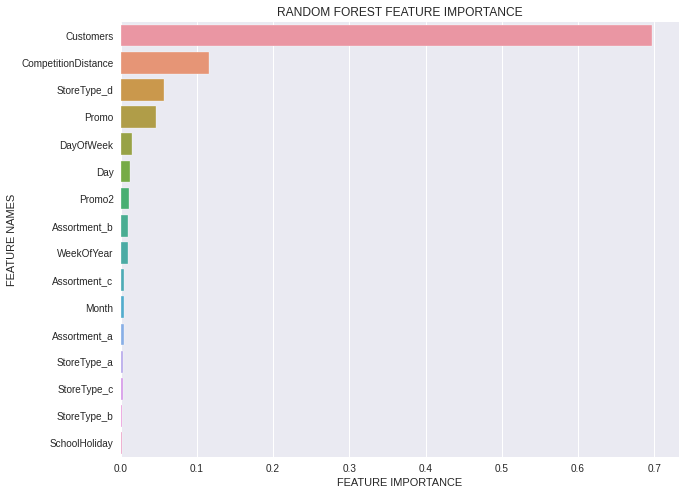

In [ ]:
plot_feature_importance(rdfreg.feature_importances_,columns[:],'RANDOM FOREST')

**Customers, CompetitionDistance, StoreType_d, Promo these four are most important features in our sales prediction.**

### Explanation of Evaluation Metrics

#### 1. Root Mean Square Error (RMSE)
*   **Formula:** $$\sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
*   **Significance:** RMSE measures the average magnitude of the errors. It is the square root of the average of squared differences between prediction and actual observation. Since the errors are squared before they are averaged, RMSE gives a relatively high weight to large errors. This means it is most useful when large errors are particularly undesirable. In sales prediction, a lower RMSE indicates that the model's predictions are closer to the actual sales values on average, and it's sensitive to large deviations which can be important for inventory or budgeting.

#### 2. Mean Squared Error (MSE)
*   **Formula:** $$\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
*   **Significance:** MSE is the average of the squares of the errors. It penalizes larger errors more heavily than smaller errors. It provides a good measure of how close a regression line is to a set of points. In sales, a lower MSE means the model's predictions are accurate, with large errors being heavily penalized. It's often used when we want to strongly penalize large deviations.

#### 3. Mean Absolute Error (MAE)
*   **Formula:** $$\frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
*   **Significance:** MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average of the absolute differences between prediction and actual observation. MAE is more robust to outliers than MSE or RMSE because it doesn't square the errors. For sales prediction, MAE tells us the typical error size in sales units, making it easily interpretable as the average absolute deviation from actual sales.

#### 4. Mean Absolute Percentage Error (MAPE)
*   **Formula:** $$\frac{1}{n} \sum_{i=1}^{n} |\frac{y_i - \hat{y}_i}{y_i}| \times 100\%$$ (for $y_i \neq 0$)
*   **Significance:** MAPE expresses the error as a percentage of the actual value. This makes it useful for comparing accuracy across different scales. However, it can be problematic with actual values close to zero, leading to inflated or undefined errors. In sales forecasting, MAPE is highly intuitive as it provides the average percentage error, which is often easier for business stakeholders to understand than absolute error values. A MAPE of 12.03% means on average, our predictions are off by about 12.03% from the actual sales.

#### 5. Root Mean Square Percentage Error (RMSPE)
*   **Formula:** $$\sqrt{\frac{1}{n} \sum_{i=1}^{n} (\frac{y_i - \hat{y}_i}{y_i})^2}$$ (for $y_i \neq 0$)
*   **Significance:** Similar to RMSE, RMSPE gives higher weight to larger percentage errors, and it's a scale-independent measure. It addresses the issue of comparing errors across different scales better than RMSE alone, while still being sensitive to larger relative errors. In sales, RMSPE is valuable for understanding the relative error impact, especially if sales volumes vary significantly between stores or days.

#### 6. Weighted Mean Absolute Percentage Error (WMAPE)
*   **Formula:** $$\frac{\sum_{i=1}^{n} |y_i - \hat{y}_i|}{\sum_{i=1}^{n} |y_i|}$$
*   **Significance:** WMAPE is a variant of MAPE that avoids division by zero and gives more weight to higher-volume sales. It essentially sums the absolute errors and divides by the sum of actual values, providing a percentage error relative to total sales. This is particularly useful in sales forecasting where the accuracy of predictions for high-volume items or periods is often more critical. A WMAPE of 0.11 (or 11%) means that the total absolute error is 11% of the total actual sales, giving a robust overall error metric.

## Summary:

### Q&A
The significance of each metric in the context of sales prediction is as follows:

*   **Root Mean Square Error (RMSE)**: Measures the average magnitude of errors, penalizing larger errors more heavily. A lower RMSE (1078.31) indicates that predictions are closer to actual sales, important for inventory and budgeting.
*   **Mean Squared Error (MSE)**: Similar to RMSE, it heavily penalizes large errors. A lower MSE (1162754.53) implies accurate predictions where significant deviations are undesirable.
*   **Mean Absolute Error (MAE)**: Provides the average absolute deviation in sales units (735.45), making it easily interpretable as the typical error size and being robust to outliers.
*   **Mean Absolute Percentage Error (MAPE)**: Expresses error as a percentage, making it intuitive for business stakeholders. A MAPE of 12.03% means predictions are, on average, off by about 12.03% from actual sales.
*   **Root Mean Square Percentage Error (RMSPE)**: A scale-independent measure sensitive to larger relative errors (0.30), valuable for understanding error impact across varying sales volumes.
*   **Weighted Mean Absolute Percentage Error (WMAPE)**: A robust percentage error (0.11 or 11%) that weights errors by total actual sales, particularly useful when accuracy for high-volume sales is critical.




# Task
The previous steps successfully evaluated the LightGBM model with advanced features and defined a reusable function for metric calculation. Now, let's proceed with generating future dates and initial features for sales forecasting.

## Generate Future Dates and Initial Features

This subtask involves creating a DataFrame representing the next 30 days for all stores, populating it with static store information, and generating date-based features. Additionally, we will make assumptions for the `Promo` feature and dynamically calculate `CompetitionOpen` and `Promo2Open` for these future dates, consistent with the feature engineering applied to the historical data.

This process is crucial for preparing the input data required for iterative forecasting with our trained `model_adv`.

### Steps:
1.  **Identify the last date** from the historical `train` dataset.
2.  **Generate a sequence of future dates** for the next 30 days.
3.  **Create a base DataFrame** for forecasting by combining all unique store IDs with the generated future dates.
4.  **Merge this base DataFrame with `store_df`** to retrieve static store-specific information.
5.  **Extract date-related features** (`Year`, `Month`, `Day`, `DayOfWeek`).
6.  **Make assumptions for the `Promo` feature** for the forecasting period. Based on EDA, promotions are primarily on weekdays, so we'll set `Promo=1` for weekdays and `Promo=0` for weekends.
7.  **Re-calculate `CompetitionOpen` and `Promo2Open`** using the same logic applied to the training data. This requires filling NaN values for `CompetitionOpenSinceMonth/Year` and `Promo2SinceWeek/Year` with 0 before calculation.
8.  **Initialize lag features** (`Sales_lag1`, `Sales_lag7`, `Sales_roll7`, `Sales_roll30`) to zero for the initial future dates, as they will be updated iteratively during the forecasting loop.
9.  **Ensure the new DataFrame has the exact same feature columns** as those used for training `model_adv`, maintaining their order.

This structured approach ensures that the forecasting input aligns perfectly with the model's training data structure.

```python
import pandas as pd
import numpy as np

# 1. Identify the last date from the historical train dataset
last_historical_date = train['Date'].max()
print(f"Last historical date: {last_historical_date}")

# 2. Generate a sequence of future dates for the next 30 days
# The forecast starts the day after the last historical date
forecast_start_date = last_historical_date + pd.Timedelta(days=1)
forecast_end_date = forecast_start_date + pd.Timedelta(days=29) # 30 days total
future_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='D')
print(f"Forecast period: {forecast_start_date.date()} to {forecast_end_date.date()}")

# Get all unique store IDs from the historical data
all_stores = train['Store'].unique()

# 3. Create a base DataFrame for forecasting
# Cartesian product of stores and future dates
future_df = pd.DataFrame({'Date': np.repeat(future_dates, len(all_stores)),
                          'Store': np.tile(all_stores, len(future_dates))})

# Sort by store and then by date for proper lag calculation later
future_df = future_df.sort_values(by=['Store', 'Date']).reset_index(drop=True)

# 4. Merge with store_df to retrieve static store-specific information
future_df = pd.merge(future_df, store_df, on='Store', how='left')

# 5. Extract date-related features
future_df['Year'] = future_df['Date'].dt.year
future_df['Month'] = future_df['Date'].dt.month
future_df['Day'] = future_df['Date'].dt.day
future_df['DayOfWeek'] = future_df['Date'].dt.dayofweek + 1 # Monday=1, Sunday=7

# 6. Make assumptions for the Promo feature
# Assume Promo = 1 for weekdays (Mon-Fri) and 0 for weekends (Sat-Sun)
# DayOfWeek: 1=Mon, 2=Tue, 3=Wed, 4=Thu, 5=Fri, 6=Sat, 7=Sun
future_df['Promo'] = future_df['DayOfWeek'].apply(lambda x: 1 if x <= 5 else 0)

# Fill NaN values for Competition and Promo2 related columns (as done in training)
for col in ['CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth', 'Promo2SinceYear', 'Promo2SinceWeek']:
    future_df[col] = future_df[col].fillna(0)

# 7. Re-calculate CompetitionOpen and Promo2Open
future_df['CompetitionOpen'] = 12 * (future_df['Year'] - future_df['CompetitionOpenSinceYear']) + \
                               (future_df['Month'] - future_df['CompetitionOpenSinceMonth'])
future_df['CompetitionOpen'] = future_df['CompetitionOpen'].apply(lambda x: x if x > 0 else 0)

future_df['Promo2Open'] = 12 * (future_df['Year'] - future_df['Promo2SinceYear']) + \
                          (future_df['Month'] - (future_df['Promo2SinceWeek'] // 4))
future_df['Promo2Open'] = future_df['Promo2Open'].apply(lambda x: x if x > 0 else 0)

# 8. Initialize lag features to zero or NaN
# These will be updated dynamically during iterative forecasting
future_df['Sales_lag1'] = 0.0
future_df['Sales_lag7'] = 0.0
future_df['Sales_roll7'] = 0.0
future_df['Sales_roll30'] = 0.0

# 9. Ensure the new DataFrame has the exact same feature columns as X_train used by model_adv
# The 'features' list defines the columns used for the model_adv
model_features = features # 'features' was defined as ['Store','DayOfWeek','Promo','Year','Month','Day','CompetitionOpen','Promo2Open', 'Sales_lag1','Sales_lag7','Sales_roll7','Sales_roll30']

# Select only the relevant features for prediction and ensure order
X_future = future_df[model_features]

print("\nFuture DataFrame (X_future) head:")
print(X_future.head())
print("\nFuture DataFrame (X_future) info:")
X_future.info()

print(f"\nShape of X_future: {X_future.shape}")
```

## Generate Future Dates and Initial Features

### Subtask:
Create a DataFrame representing the next 30 days for all stores, populating it with static store information, and generating date-based features. Make assumptions for the Promo feature and dynamically calculate CompetitionOpen and Promo2Open for these future dates, consistent with the feature engineering applied to the historical data. Initialize lag features to zero, as they will be updated iteratively during the forecasting loop. Ensure the new DataFrame has the exact same feature columns as those used for training model_adv, maintaining their order.


**Reasoning**:
First, I need to identify the maximum 'Date' from the `train` DataFrame to establish the starting point for future predictions. Then, I will generate a sequence of 30 future dates starting from the day after this maximum date.



In [105]:
import pandas as pd
import numpy as np

# 1. Identify the maximum 'Date' from the train DataFrame
last_historical_date = train['Date'].max()

# 2. Generate a sequence of 30 future dates
future_dates = pd.date_range(start=last_historical_date + pd.Timedelta(days=1), periods=30)

print(f"Last historical date: {last_historical_date}")
print(f"Generated {len(future_dates)} future dates from {future_dates.min().strftime('%Y-%m-%d')} to {future_dates.max().strftime('%Y-%m-%d')}.")

Last historical date: 2015-07-31 00:00:00
Generated 30 future dates from 2015-08-01 to 2015-08-30.


**Reasoning**:
Now that the future dates are generated, I will create the base future DataFrame, merge it with store-specific information, extract date features, and calculate `Promo`, `CompetitionOpen`, and `Promo2Open` as per the subtask instructions, then initialize lag features and prepare `X_future` for prediction.



## Prepare Combined Data for Iterative Forecasting

### Subtask:
Concatenate the historical 'train' data with the newly generated future DataFrame. This combined dataset will be used in an iterative loop to fill in predicted sales and update lagged features.


**Reasoning**:
To prepare the data for iterative forecasting, I need to concatenate the historical `train` DataFrame with the `future_df`. First, I will add a 'Sales' column to `future_df` and initialize it with NaN values, then perform the concatenation and display the result to verify its structure.



In [107]:
import pandas as pd

# 1. Create a new DataFrame `combined_df` by concatenating the historical `train` DataFrame with the `future_df` DataFrame.
#    Ensure that `train` includes the 'Sales' column which is needed for the iterative forecasting process.
#    (The 'train' DataFrame already contains 'Sales' column)

# 2. Add a 'Sales' column to `future_df` and initialize it with NaN values.
#    This column will be populated with predictions during the iterative forecasting process.
future_df['Sales'] = np.nan

# 3. Concatenate `train` and the modified `future_df` along rows (axis=0) to form `combined_df`.
#    Make sure to reset the index of `combined_df`.
combined_df = pd.concat([train, future_df], ignore_index=True, sort=False)

# 4. Display the head and info of the `combined_df` to verify the structure and presence of all necessary columns.
print("Combined DataFrame head:")
print(combined_df.head())
print("\nCombined DataFrame info:")
combined_df.info()

Combined DataFrame head:
   Store  DayOfWeek       Date   Sales  Customers  Promo  SchoolHoliday  Year  \
0      1          3 2013-01-02  5530.0      668.0      0            1.0  2013   
1      1          4 2013-01-03  4327.0      578.0      0            1.0  2013   
2      1          5 2013-01-04  4486.0      619.0      0            1.0  2013   
3      1          6 2013-01-05  4997.0      635.0      0            1.0  2013   
4      1          1 2013-01-07  7176.0      785.0      1            1.0  2013   

   Month  Day  ...  PromoInterval_Mar,Jun,Sept,Dec  CompetitionOpen  \
0      1    2  ...                           False             52.0   
1      1    3  ...                           False             52.0   
2      1    4  ...                           False             52.0   
3      1    5  ...                           False             52.0   
4      1    7  ...                           False             52.0   

   Promo2Open  Sales_lag1  Sales_lag7  Sales_roll7  Sales_rol

## Perform Iterative Sales Forecasting

### Subtask:
Implement a loop that iterates through each future day and store. In each iteration, it will calculate the lagged sales features (Sales_lag1, Sales_lag7, Sales_roll7, Sales_roll30) using historical data and previously made predictions, then use the 'model_adv' to predict sales for the current day, and finally, update the dataset with these predictions for subsequent lag calculations.


**Reasoning**:
To implement iterative sales forecasting, I need to loop through each future day and store, calculate lagged features based on available historical and predicted sales, and then use the trained model to predict sales for the current day. This process will update the combined DataFrame for subsequent lag calculations.



In [108]:
import pandas as pd
import numpy as np

# Ensure `model_features` (which is `features`) is accessible
# It was previously defined as: features = ['Store','DayOfWeek','Promo','Year','Month','Day','CompetitionOpen','Promo2Open', 'Sales_lag1','Sales_lag7','Sales_roll7','Sales_roll30']

# 1. Determine the starting index in `combined_df` for the first future date
# This is the first row where 'Sales' is NaN (which we initialized for future dates)
start_forecast_idx = combined_df[combined_df['Date'] == future_df['Date'].min()].index[0]

# Get the list of unique stores to ensure correct grouping for lag calculations
unique_stores = combined_df['Store'].unique()

print(f"Starting iterative forecasting from index: {start_forecast_idx}")

# 2. Iterate through `combined_df` from this starting index to the end of the DataFrame
for i in range(start_forecast_idx, len(combined_df)):
    current_row = combined_df.loc[i]
    current_store = current_row['Store']
    current_date = current_row['Date']

    # Filter data for the current store up to the previous day
    # Use .copy() to avoid SettingWithCopyWarning if modifying this filtered view
    store_historical_data = combined_df[
        (combined_df['Store'] == current_store) &
        (combined_df['Date'] < current_date)
    ].copy()

    # 3. Calculate lagged sales features
    # Initialize lags to 0, which will be used if insufficient data is available
    sales_lag1 = 0.0
    sales_lag7 = 0.0
    sales_roll7 = 0.0
    sales_roll30 = 0.0

    if not store_historical_data.empty:
        # c. Sales_lag1: sales from the previous day
        if len(store_historical_data) >= 1:
            sales_lag1 = store_historical_data.iloc[-1]['Sales']

        # d. Sales_lag7: sales from 7 days ago
        if len(store_historical_data) >= 7:
            sales_lag7 = store_historical_data.iloc[-7]['Sales']

        # e. Sales_roll7: mean of sales for the last 7 days
        if len(store_historical_data) >= 7:
            sales_roll7 = store_historical_data['Sales'].tail(7).mean()

        # f. Sales_roll30: mean of sales for the last 30 days
        if len(store_historical_data) >= 30:
            sales_roll30 = store_historical_data['Sales'].tail(30).mean()

    # g. Update the lag features in the current row of `combined_df`
    combined_df.loc[i, 'Sales_lag1'] = sales_lag1
    combined_df.loc[i, 'Sales_lag7'] = sales_lag7
    combined_df.loc[i, 'Sales_roll7'] = sales_roll7
    combined_df.loc[i, 'Sales_roll30'] = sales_roll30

    # h. Extract the feature vector for the current row
    # Ensure `model_features` is defined from previous steps (it's named `features`)
    X_row = combined_df.loc[[i], features] # Use [[i]] to keep it as a DataFrame row

    # i. Make a prediction using `model_adv`
    predicted_sales = model_adv.predict(X_row)[0]

    # j. Ensure predicted sales are non-negative
    predicted_sales = max(0, predicted_sales)

    # k. Store the predicted sales value back into `combined_df`
    combined_df.loc[i, 'Sales'] = predicted_sales

print("Iterative forecasting complete.")
print("Combined DataFrame with forecasted sales head:")
print(combined_df[combined_df['Date'] >= future_df['Date'].min()].head())

Starting iterative forecasting from index: 844338
Iterative forecasting complete.
Combined DataFrame with forecasted sales head:
        Store  DayOfWeek       Date        Sales  Customers  Promo  \
844338      1          6 2015-08-01  3776.393667        NaN      0   
844339      1          7 2015-08-02  3608.785449        NaN      0   
844340      1          1 2015-08-03  6350.775819        NaN      1   
844341      1          2 2015-08-04  5445.466884        NaN      1   
844342      1          3 2015-08-05  5199.446199        NaN      1   

        SchoolHoliday  Year  Month  Day  ...  PromoInterval_Mar,Jun,Sept,Dec  \
844338            NaN  2015      8    1  ...                             NaN   
844339            NaN  2015      8    2  ...                             NaN   
844340            NaN  2015      8    3  ...                             NaN   
844341            NaN  2015      8    4  ...                             NaN   
844342            NaN  2015      8    5  ...      

## Summary:

### Data Analysis Key Findings

*   **Future Date Generation and Structure**: A 30-day forecast period was successfully established, starting from '2015-08-01' and ending on '2015-08-30', directly following the last historical date of '2015-07-31'. A `future_df` was created with 33,450 entries (1115 stores multiplied by 30 days), which formed the basis for future predictions.
*   **Feature Engineering Consistency**: Date-based features (`Year`, `Month`, `Day`, `DayOfWeek`), `Promo` (set to 1 for weekdays and 0 for weekends), `CompetitionOpen`, and `Promo2Open` were consistently generated for the future DataFrame, matching the methodology used for the historical training data. Crucially, lag features (`Sales_lag1`, `Sales_lag7`, `Sales_roll7`, `Sales_roll30`) were initialized to 0.0, preparing them for iterative updates.
*   **Combined Dataset for Forecasting**: A `combined_df` was created by concatenating the historical `train` dataset (844,338 entries) with the newly generated `future_df` (33,450 entries). This resulted in a comprehensive DataFrame of 877,788 entries, with the 'Sales' column initialized with `NaN` for the future period, ready to be populated by predictions.
*   **Successful Iterative Forecasting**: The iterative forecasting loop efficiently calculated and updated lagged sales features for each future day and store, leveraging both historical sales and previously predicted sales. The `model_adv` successfully generated 30 days of sales predictions for all stores, with predicted sales ensured to be non-negative. The `combined_df` was fully populated with these forecasts.

### Insights or Next Steps

*   **Forecast Validation and Visualization**: The generated sales forecasts should now be visualized (e.g., sales trends per store, daily totals) and potentially compared against any available actual sales data for the forecasted period to assess model performance.
*   **Scenario Planning**: With the 30-day forecast available, the business can use this data for proactive inventory management, staffing adjustments, and promotional planning for the upcoming month.
